In [1]:
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')
 
# ── Plotting style ──────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 150,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})




from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.linear_model import Ridge
from sklearn.model_selection import LeaveOneOut, cross_val_predict, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay)





In [2]:
df_full = pd.read_csv('data/cleaned/final_dataset.csv')
print(f"Shape: {df_full.shape}")
print(f"Unique states: {df_full['state_name'].nunique()}")
print(f"Years: {sorted(df_full['Year'].dropna().unique())}")
print(f"\nColumns:\n{df_full.columns.tolist()}")
print(f"\nMissing values:\n{df_full.isnull().sum()[df_full.isnull().sum() > 0]}")
 

Shape: (36, 56)
Unique states: 36
Years: ['Calendar Year (Jan - Dec), 2025']

Columns:
['sno', 'state_name', 'rural_accounts', 'urban_accounts', 'total_accounts', 'total_balance_crore', 'rupay_cards', 'total_balance', 'avg_balance_per_account', 'rupay_activation_ratio', 'rural_share', 'urban_share', 'households', 'population', 'male_pop', 'female_pop', 'literate_pop', 'male_literate', 'female_literate', 'sc_population', 'st_population', 'working_pop', 'female_working_pop', 'literacy_rate', 'male_literacy_rate', 'female_literacy_rate', 'female_workforce_pct', 'sc_share', 'st_share', 'avg_household_size', 'women_bank_account_pct', 'female_literacy_nfhs', 'male_literacy_nfhs', 'female_workforce_pct_nfhs', 'women_mobile_pct', 'electricity_access_pct', 'clean_water_pct', 'women_property_ownership_pct', 'literacy_gender_gap', 'Country', 'Year', 'Name Of The Region', 'Additional Info', 'Distribution Of Offices Of Scheduled Commercial Banks (UOM:Number), Scaling Factor:1', 'Credit-Deposit Rati

In [3]:
STATE_COLS = [
    'state_name',
    'rural_accounts', 'urban_accounts', 'total_accounts',
    'total_balance_crore', 'rupay_cards',
    'avg_balance_per_account', 'rupay_activation_ratio',
    'rural_share', 'urban_share', 'accounts_per_capita',
    'literacy_rate', 'male_literacy_rate', 'female_literacy_rate',
    'female_workforce_pct', 'sc_share', 'st_share',
    'avg_household_size', 'population',
    'women_bank_account_pct', 'female_literacy_nfhs',
    'male_literacy_nfhs', 'female_workforce_pct_nfhs',
    'women_mobile_pct', 'electricity_access_pct',
    'clean_water_pct', 'women_property_ownership_pct',
    'literacy_gender_gap', 'gender_gap',
    'Name Of The Region'
]
# Keep only columns that exist
STATE_COLS = [c for c in STATE_COLS if c in df_full.columns]
df_state = df_full[STATE_COLS].drop_duplicates(subset='state_name').reset_index(drop=True)
 
# 2. Panel dataframe (all years, for time-series analysis)
RBI_COL_BRANCHES = "Distribution Of Offices Of Scheduled Commercial Banks (UOM:Number), Scaling Factor:1"
RBI_COL_CD_SANCTION = "Credit-Deposit Ratio Of Scheduled Commercial Banks According To Place Of Sanction (UOM:Ratio), Scaling Factor:1"
RBI_COL_DEPOSITS = "Deposits By Scheduled Commercial Banks In India (UOM:INR(IndianRupees)), Scaling Factor:10000000"
RBI_COL_CREDIT = "Credit By Scheduled Commercial Banks In India (UOM:INR(IndianRupees)), Scaling Factor:10000000"
 
df_panel = df_full[['state_name', 'Year',
                     RBI_COL_BRANCHES, RBI_COL_CD_SANCTION,
                     RBI_COL_DEPOSITS, RBI_COL_CREDIT,
                     'rupay_activation_ratio', 'avg_balance_per_account',
                     'accounts_per_capita', 'Name Of The Region']].copy()
df_panel.columns = ['state_name', 'year', 'scb_branches',
                    'cd_ratio', 'deposits', 'credit',
                    'rupay_ratio', 'avg_balance',
                    'accounts_per_capita', 'region']
df_panel['year'] = pd.to_numeric(df_panel['year'].astype(str).str.extract(r'(\d{4})')[0])
 
print(f"\nState-level df: {df_state.shape}")
print(f"Panel df: {df_panel.shape}")
 


State-level df: (36, 29)
Panel df: (36, 10)


       rupay_activation_ratio  avg_balance_per_account  accounts_per_capita  literacy_rate  women_bank_account_pct  literacy_gender_gap  rural_share
count                  36.000                   36.000               36.000         36.000                  36.000               36.000       36.000
mean                    0.676                 6335.377                0.390         67.293                  78.081                8.036        0.741
std                     0.064                 2913.634                0.184          8.544                  15.855               20.855        0.188
min                     0.487                 2953.102                0.078         50.437                  -6.250              -87.350        0.091
25%                     0.641                 5007.805                0.252         60.196                  76.200                5.712        0.691
50%                     0.683                 5746.623                0.350         67.427                

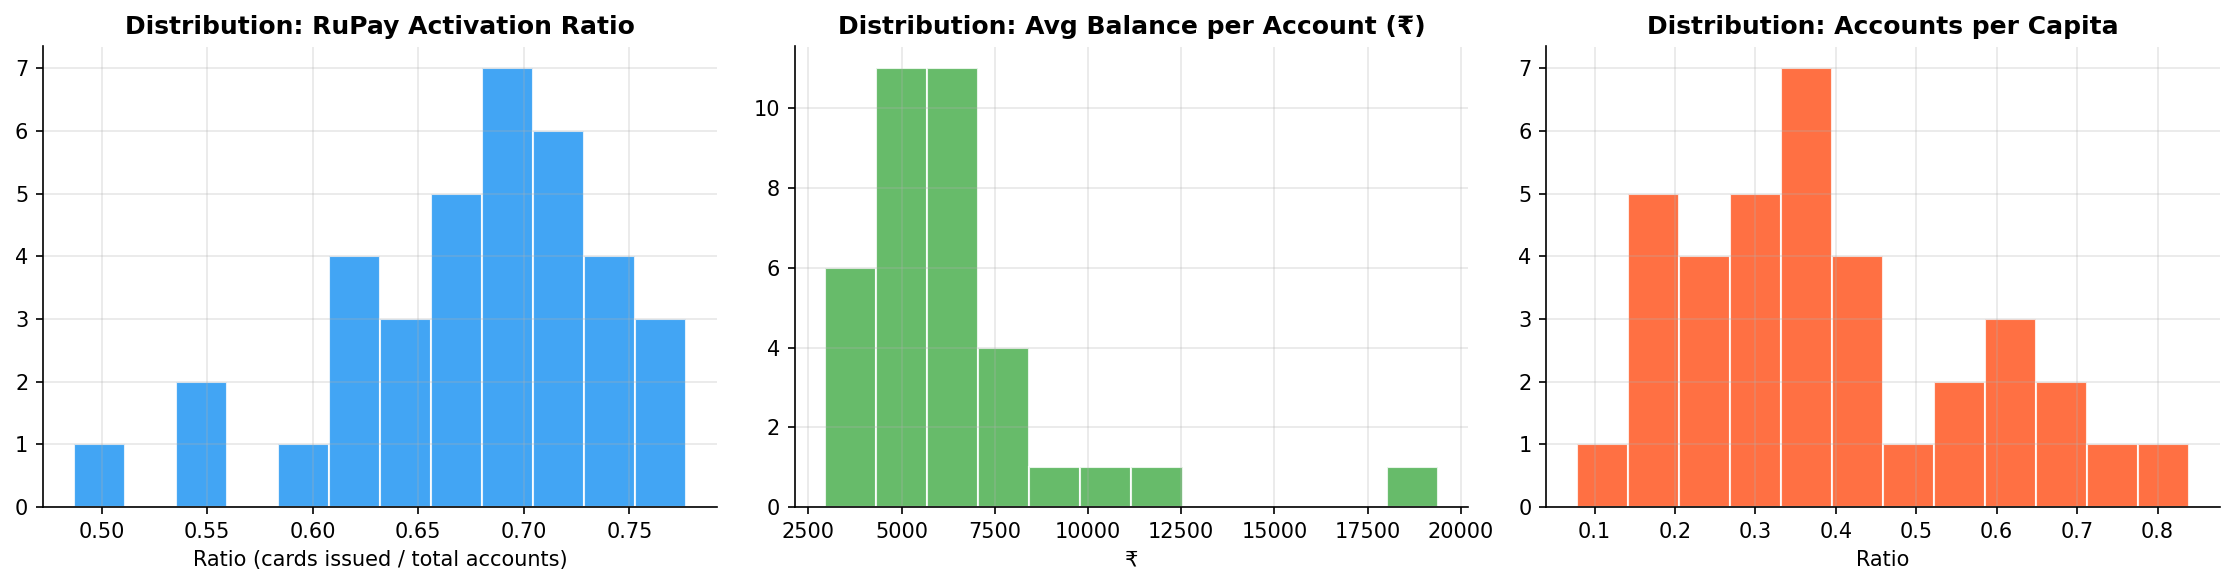

Saved: 01_distributions.png


In [5]:
key_vars = [
    'rupay_activation_ratio', 'avg_balance_per_account',
    'accounts_per_capita', 'literacy_rate',
    'women_bank_account_pct', 'literacy_gender_gap',
    'rural_share'
]
key_vars = [v for v in key_vars if v in df_state.columns]
print(df_state[key_vars].describe().round(3).to_string())
 
# Distribution plots for key PMJDY variables
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
 
axes[0].hist(df_state['rupay_activation_ratio'].dropna(), bins=12,
             color='#2196F3', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribution: RuPay Activation Ratio', fontweight='bold')
axes[0].set_xlabel('Ratio (cards issued / total accounts)')
 
axes[1].hist(df_state['avg_balance_per_account'].dropna(), bins=12,
             color='#4CAF50', edgecolor='white', alpha=0.85)
axes[1].set_title('Distribution: Avg Balance per Account (₹)', fontweight='bold')
axes[1].set_xlabel('₹')
 
axes[2].hist(df_state['accounts_per_capita'].dropna(), bins=12,
             color='#FF5722', edgecolor='white', alpha=0.85)
axes[2].set_title('Distribution: Accounts per Capita', fontweight='bold')
axes[2].set_xlabel('Ratio')
 
plt.tight_layout()
plt.savefig(r"C:\Users\Mihika\Desktop\dsm_project_final\dsm project\results\visualisations\01_distributions.png", bbox_inches='tight')
plt.show()
print("Saved: 01_distributions.png")
 

In [6]:
# EDA 


# ── 1. Check for true duplicates (same state + same year) ───
true_dupes = df_full.duplicated(subset=['state_name', 'Year'], keep=False)
print(f"True duplicate rows (same state + year): {true_dupes.sum()}")
if true_dupes.sum() > 0:
    print(df_full[true_dupes][['state_name', 'Year']].to_string())
    df_full = df_full.drop_duplicates(subset=['state_name', 'Year'], keep='first')
    print("✅ Duplicates dropped.")





# ── 3. Missing values — full picture ────────────────────────
print("\n--- Missing Values in State-Level Dataset ---")
missing = df_state.isnull().sum()
missing_pct = (missing / len(df_state) * 100).round(1)
missing_report = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)
print(missing_report.to_string())

# ── 4. Handle missing values ────────────────────────────────
# NFHS columns are missing for some UTs (Andaman, Lakshadweep etc.)
# Do NOT impute these — flag them and exclude from NFHS-specific analysis

nfhs_cols = ['women_bank_account_pct', 'female_literacy_nfhs',
             'male_literacy_nfhs', 'female_workforce_pct_nfhs',
             'women_mobile_pct', 'electricity_access_pct',
             'clean_water_pct', 'women_property_ownership_pct']
nfhs_cols = [c for c in nfhs_cols if c in df_state.columns]

missing_nfhs_states = df_state[df_state[nfhs_cols].isnull().any(axis=1)]['state_name'].tolist()
print(f"\nStates with missing NFHS data (will be excluded from NFHS analysis):")
print(missing_nfhs_states)

# For RBI panel data — missing years for some states
print(f"\n--- Missing Values in Panel Dataset ---")
panel_missing = df_panel.isnull().sum()
print(panel_missing[panel_missing > 0].to_string())

# ── 5. Outlier check on key variables ───────────────────────
print("\n--- Outlier Check (Z-score > 3) ---")
outlier_cols = ['rupay_activation_ratio', 'avg_balance_per_account', 'accounts_per_capita']
outlier_cols = [c for c in outlier_cols if c in df_state.columns]

for col in outlier_cols:
    sub = df_state[['state_name', col]].dropna()
    z_scores = np.abs(stats.zscore(sub[col]))
    outliers = sub[z_scores > 2.5]
    if len(outliers) > 0:
        print(f"\n{col} — potential outliers:")
        print(outliers.to_string(index=False))
    else:
        print(f"{col} — no outliers detected")

print(f"  Rows in full dataset:     {len(df_full)}")
print(f"  Unique states:            {df_full['state_name'].nunique()}")
print(f"  States with full data:    {len(df_state.dropna(subset=outlier_cols))}")
print(f"  States missing NFHS data: {len(missing_nfhs_states)}")

True duplicate rows (same state + year): 0

--- Missing Values in State-Level Dataset ---
                    Missing Count  Missing %
Name Of The Region              3        8.3

States with missing NFHS data (will be excluded from NFHS analysis):
[]

--- Missing Values in Panel Dataset ---
year            3
scb_branches    3
cd_ratio        3
deposits        3
credit          3
region          3

--- Outlier Check (Z-score > 3) ---

rupay_activation_ratio — potential outliers:
state_name  rupay_activation_ratio
   Mizoram                0.486685

avg_balance_per_account — potential outliers:
 state_name  avg_balance_per_account
Lakshadweep             19380.207846
accounts_per_capita — no outliers detected
  Rows in full dataset:     36
  Unique states:            36
  States with full data:    36
  States missing NFHS data: 0


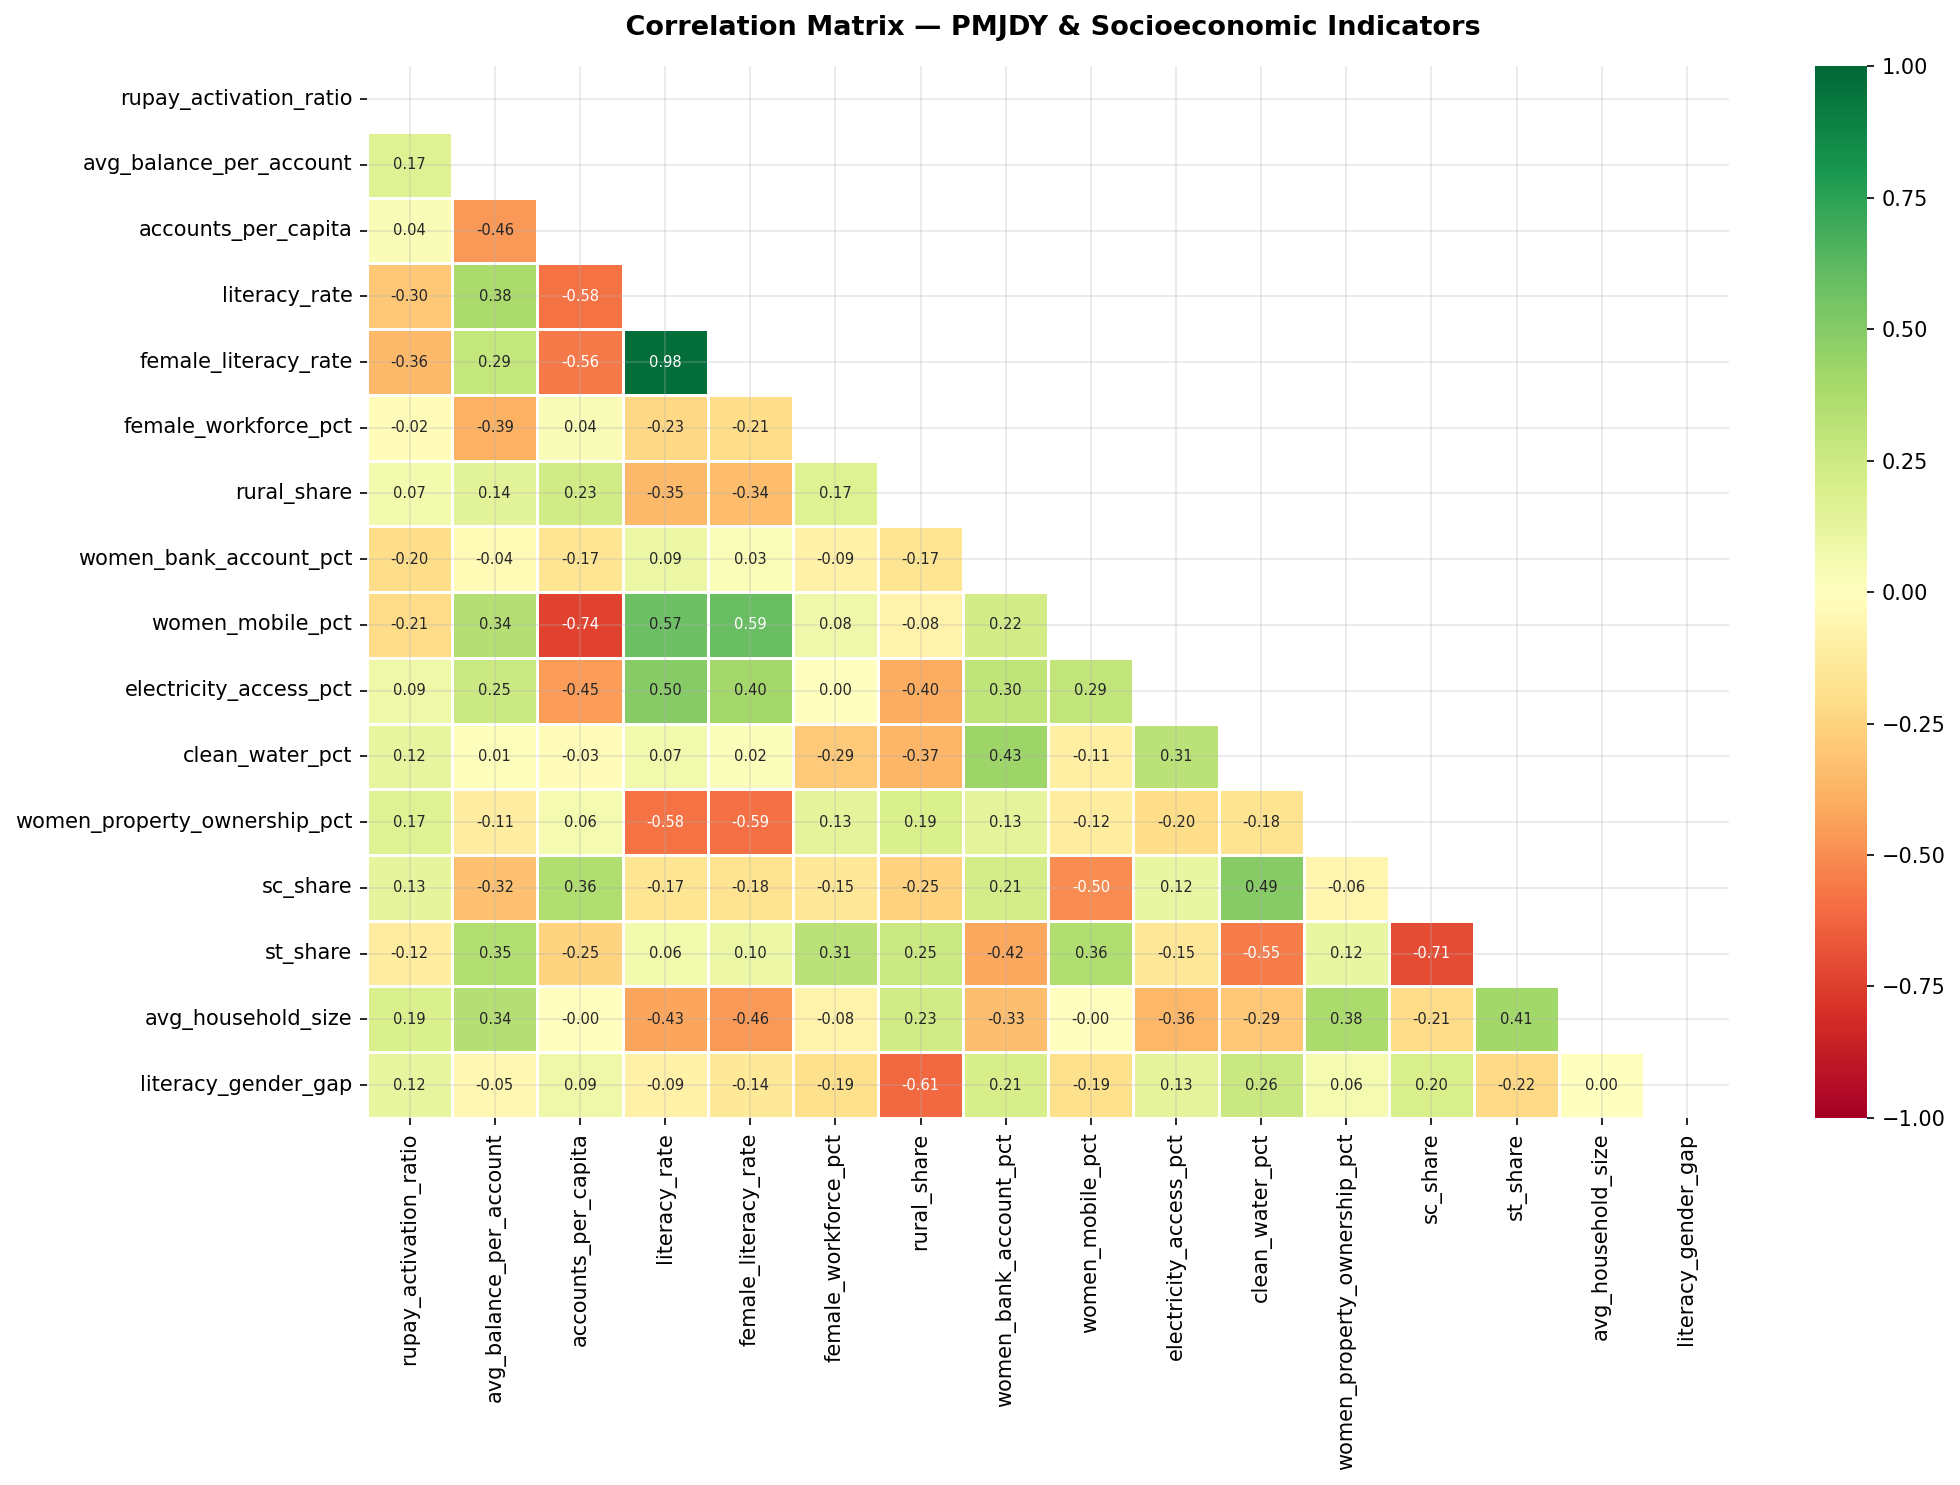

Saved: 02_correlation_heatmap.png

Top correlations with RuPay Activation Ratio:
female_literacy_rate           -0.358
literacy_rate                  -0.299
women_mobile_pct               -0.214
women_bank_account_pct         -0.204
avg_household_size              0.191
women_property_ownership_pct    0.170
sc_share                        0.131
clean_water_pct                 0.122
st_share                       -0.121
literacy_gender_gap             0.120
electricity_access_pct          0.088
rural_share                     0.065
female_workforce_pct           -0.022

Top correlations with Avg Balance per Account:
female_workforce_pct           -0.386
literacy_rate                   0.375
st_share                        0.349
avg_household_size              0.339
women_mobile_pct                0.339
sc_share                       -0.321
female_literacy_rate            0.286
electricity_access_pct          0.253
rural_share                     0.141
women_property_ownership_pct   -0.1

In [32]:
targets = ['rupay_activation_ratio', 'avg_balance_per_account', 'accounts_per_capita']
 
# Define predictor variables
predictors = [
    'literacy_rate', 'female_literacy_rate', 'female_workforce_pct',
    'rural_share', 'women_bank_account_pct', 'women_mobile_pct',
    'electricity_access_pct', 'clean_water_pct',
    'women_property_ownership_pct', 'sc_share', 'st_share',
    'avg_household_size', 'literacy_gender_gap'
]
predictors = [p for p in predictors if p in df_state.columns]
 
# Pearson correlation matrix
corr_data = df_state[targets + predictors].dropna()
corr_matrix = corr_data.corr()
 
# Plot heatmap — full matrix
fig, ax = plt.subplots(figsize=(14, 10))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True  # upper triangle
 
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax, annot_kws={'size': 7}
)
ax.set_title(' Correlation Matrix — PMJDY & Socioeconomic Indicators',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(r"C:\Users\Mihika\Desktop\dsm_project_final\dsm project\results\visualisations\02_correlation_heatmap.png", bbox_inches='tight')
plt.show()
print("Saved: 02_correlation_heatmap.png")
 
# Print top correlations with RuPay ratio (your key activity indicator)
print("\nTop correlations with RuPay Activation Ratio:")
corr_rupay = corr_matrix['rupay_activation_ratio'].drop(targets).sort_values(key=abs, ascending=False)
print(corr_rupay.round(3).to_string())
 
print("\nTop correlations with Avg Balance per Account:")
corr_bal = corr_matrix['avg_balance_per_account'].drop(targets).sort_values(key=abs, ascending=False)
print(corr_bal.round(3).to_string())
 
# Spearman correlation (rank-based, more robust for skewed data)
print("\n--- Spearman Correlations with RuPay Activation Ratio ---")
for pred in predictors:
    sub = df_state[['rupay_activation_ratio', pred]].dropna()
    if len(sub) > 5:
        r, p = spearmanr(sub['rupay_activation_ratio'], sub[pred])
        sig = "***" if p < 0.01 else ("**" if p < 0.05 else ("*" if p < 0.1 else ""))
        print(f"  {pred:<40} r={r:>6.3f}  p={p:.3f} {sig}")

In [9]:
# Derive gender gap variables
df_state['account_gender_gap'] = (
    100 - df_state['women_bank_account_pct']  
    # proxy: if 100% = full parity, gap = how far below parity women are
)

df_state['literacy_gender_gap_nfhs'] = (
    df_state['male_literacy_nfhs'] - df_state['female_literacy_nfhs']
)

# Replace 'gender_gap' references in Cell 8 with 'account_gender_gap'

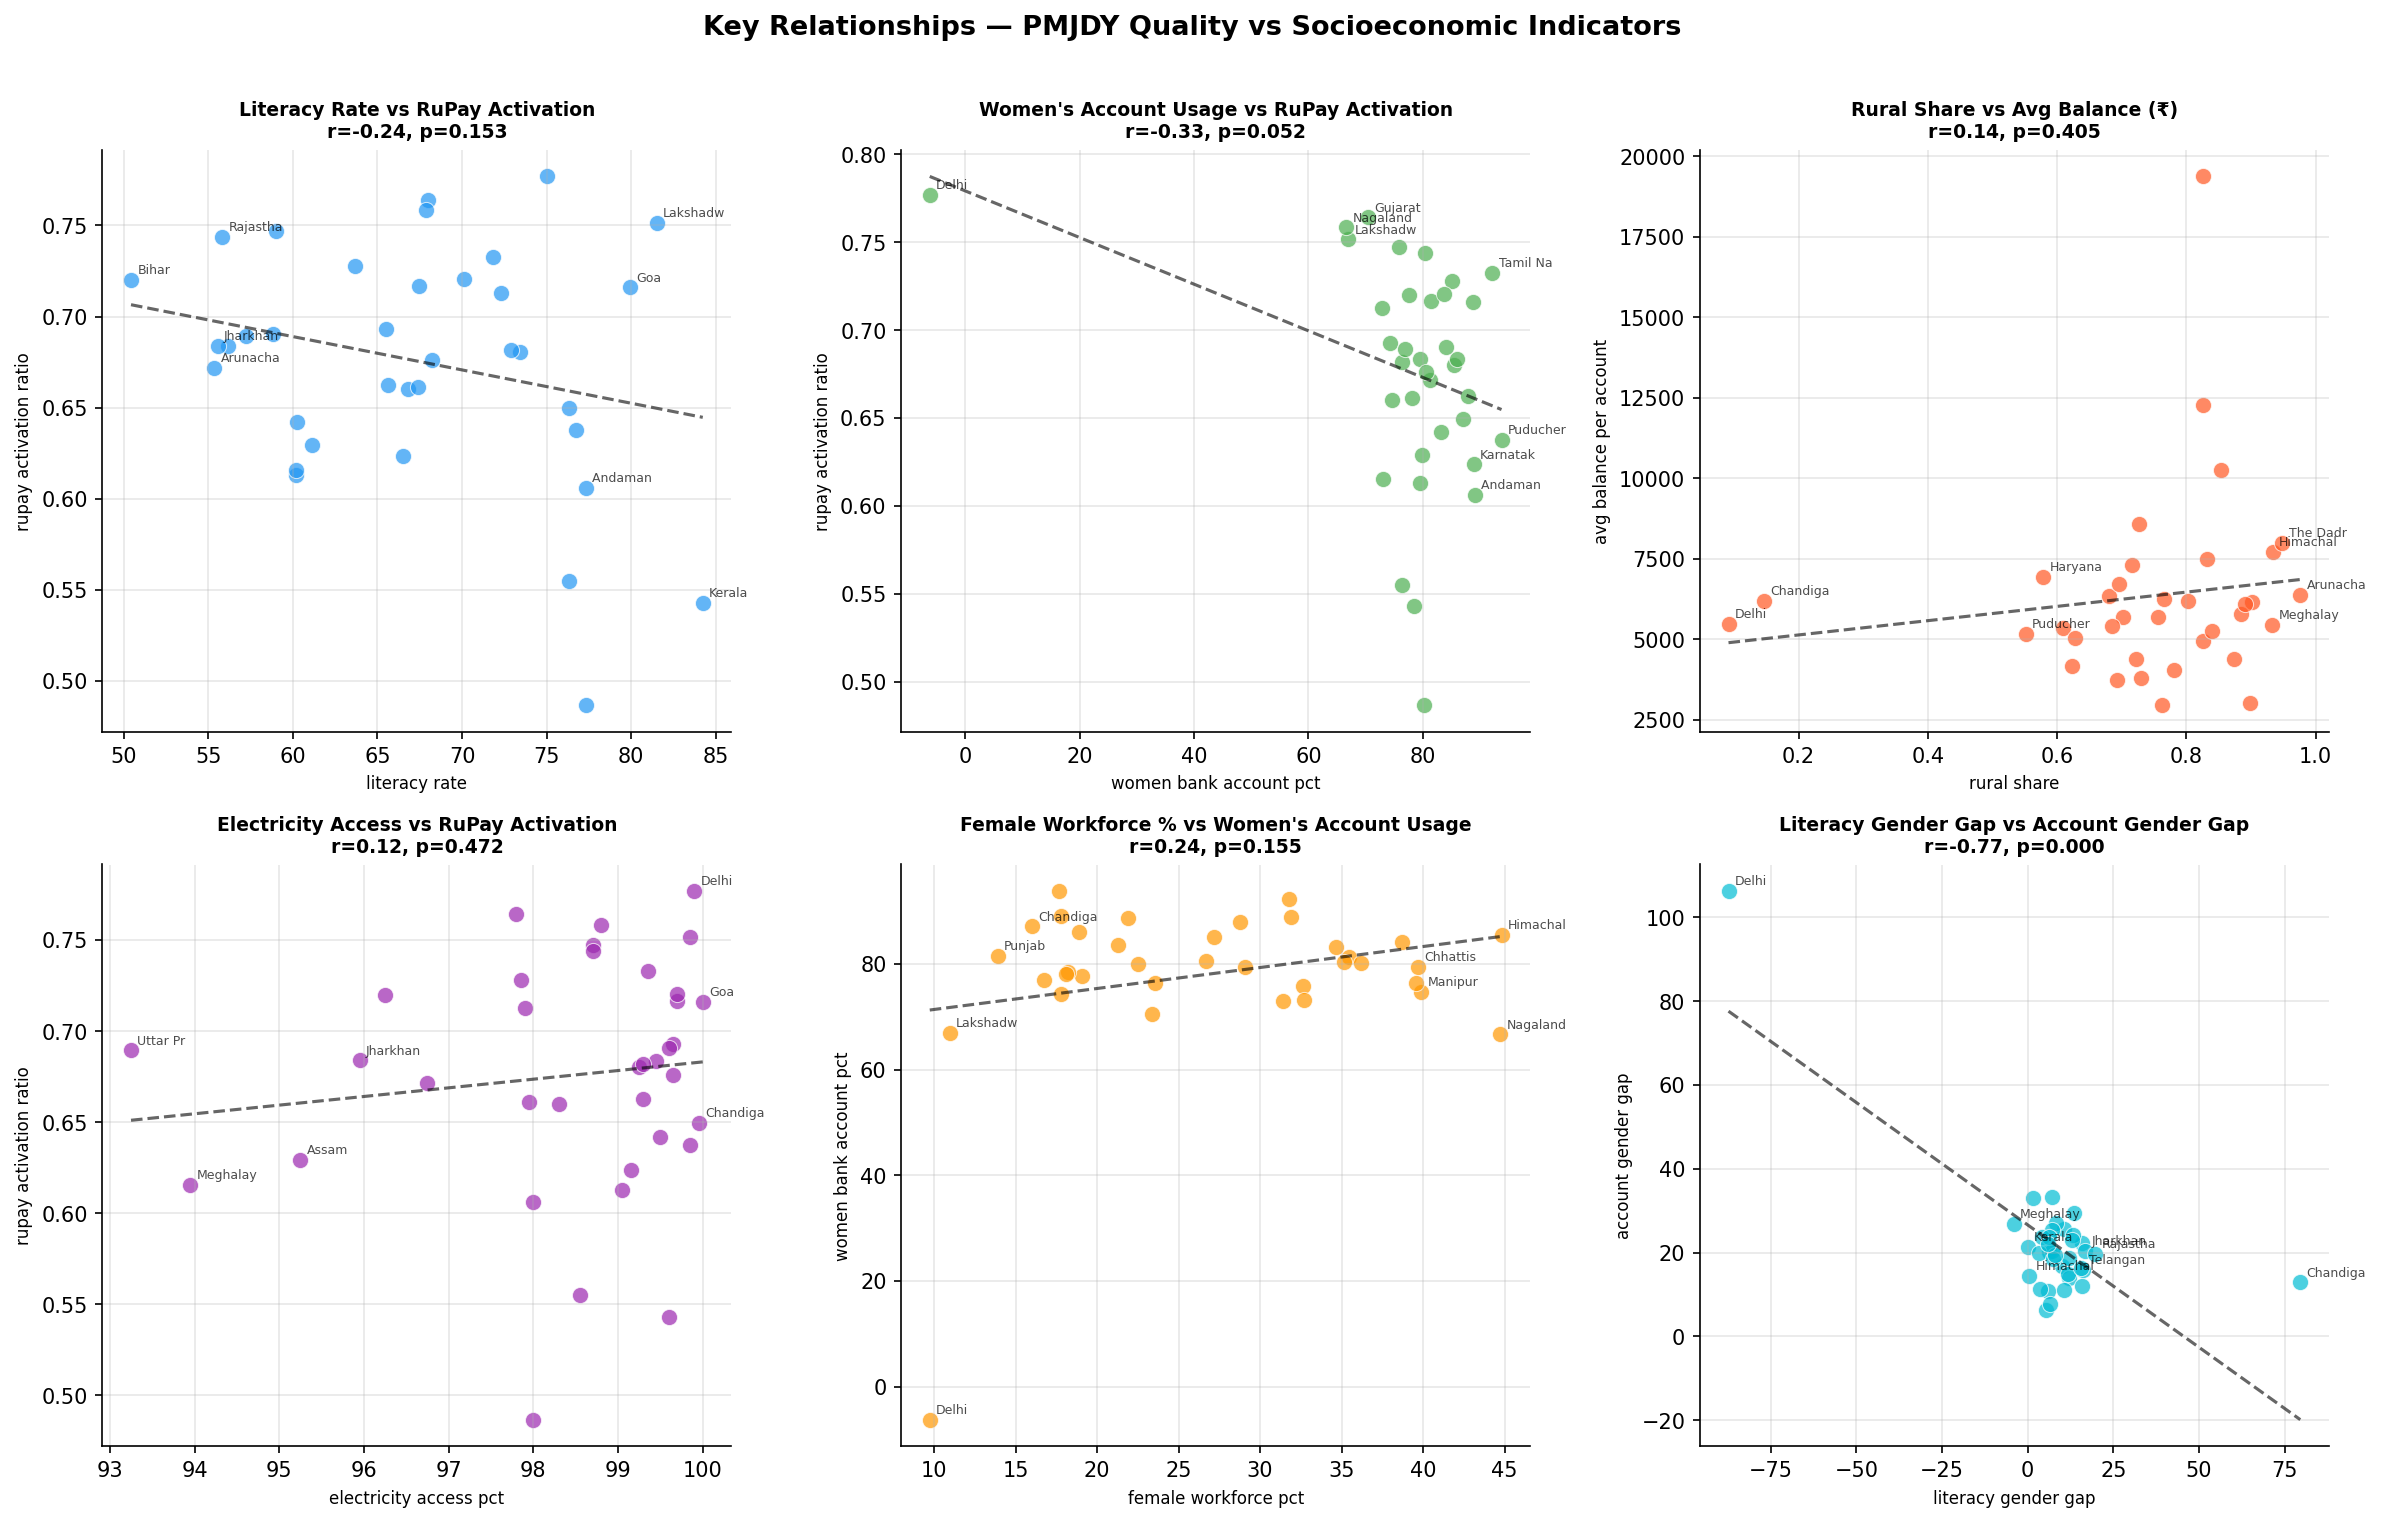

Saved: 03_scatter_plots.png


In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
 
scatter_pairs = [
    ('literacy_rate',           'rupay_activation_ratio',    'Literacy Rate vs RuPay Activation'),
    ('women_bank_account_pct',  'rupay_activation_ratio',    'Women\'s Account Usage vs RuPay Activation'),
    ('rural_share',             'avg_balance_per_account',   'Rural Share vs Avg Balance (₹)'),
    ('electricity_access_pct',  'rupay_activation_ratio',    'Electricity Access vs RuPay Activation'),
    ('female_workforce_pct',    'women_bank_account_pct',    'Female Workforce % vs Women\'s Account Usage'),
    ('literacy_gender_gap',     'account_gender_gap',                'Literacy Gender Gap vs Account Gender Gap'),
]
 
colors = ['#2196F3', '#4CAF50', '#FF5722', '#9C27B0', '#FF9800', '#00BCD4']
 
for i, (x_col, y_col, title) in enumerate(scatter_pairs):
    if x_col not in df_state.columns or y_col not in df_state.columns:
        continue
    sub = df_state[[x_col, y_col, 'state_name']].dropna()
    ax = axes[i]
    ax.scatter(sub[x_col], sub[y_col], color=colors[i], alpha=0.7, s=60, edgecolors='white', linewidth=0.5)
 
    # Regression line
    if len(sub) > 3:
        m, b, r, p, _ = stats.linregress(sub[x_col], sub[y_col])
        x_line = np.linspace(sub[x_col].min(), sub[x_col].max(), 100)
        ax.plot(x_line, m * x_line + b, color='black', linewidth=1.5, alpha=0.6, linestyle='--')
        ax.set_title(f'{title}\nr={r:.2f}, p={p:.3f}', fontsize=9, fontweight='bold')
    else:
        ax.set_title(title, fontsize=9, fontweight='bold')
 
    ax.set_xlabel(x_col.replace('_', ' '), fontsize=8)
    ax.set_ylabel(y_col.replace('_', ' '), fontsize=8)
 
    # Label notable states
    for _, row in sub.iterrows():
        if row[x_col] > sub[x_col].quantile(0.9) or row[x_col] < sub[x_col].quantile(0.1):
            ax.annotate(row['state_name'][:8], (row[x_col], row[y_col]),
                        fontsize=6, alpha=0.7, xytext=(3, 3), textcoords='offset points')
 
plt.suptitle('Key Relationships — PMJDY Quality vs Socioeconomic Indicators',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(r"C:\Users\Mihika\Desktop\dsm_project_final\dsm project\results\visualisations\03_scatter_plots.png", bbox_inches='tight')
plt.show()
print("Saved: 03_scatter_plots.png")


Model 1: Predicting RuPay Activation Ratio
R² = 0.301 | CV R² = -0.413 ± 0.723

Coefficients (standardized — larger abs value = more influence):
               Feature  Coefficient
         literacy_rate      -0.0303
electricity_access_pct       0.0254
women_bank_account_pct      -0.0249
  female_workforce_pct      -0.0096
           rural_share       0.0078
              sc_share       0.0021

Model 2: Predicting Avg Balance per Account
R² = 0.418 | CV R² = -4.022 ± 5.811
                     Feature  Coefficient
                 rural_share    1579.8874
        female_workforce_pct   -1171.8750
               literacy_rate    1154.1975
      electricity_access_pct     831.3591
women_property_ownership_pct     527.0082
      women_bank_account_pct    -485.9365
             clean_water_pct      -4.8993


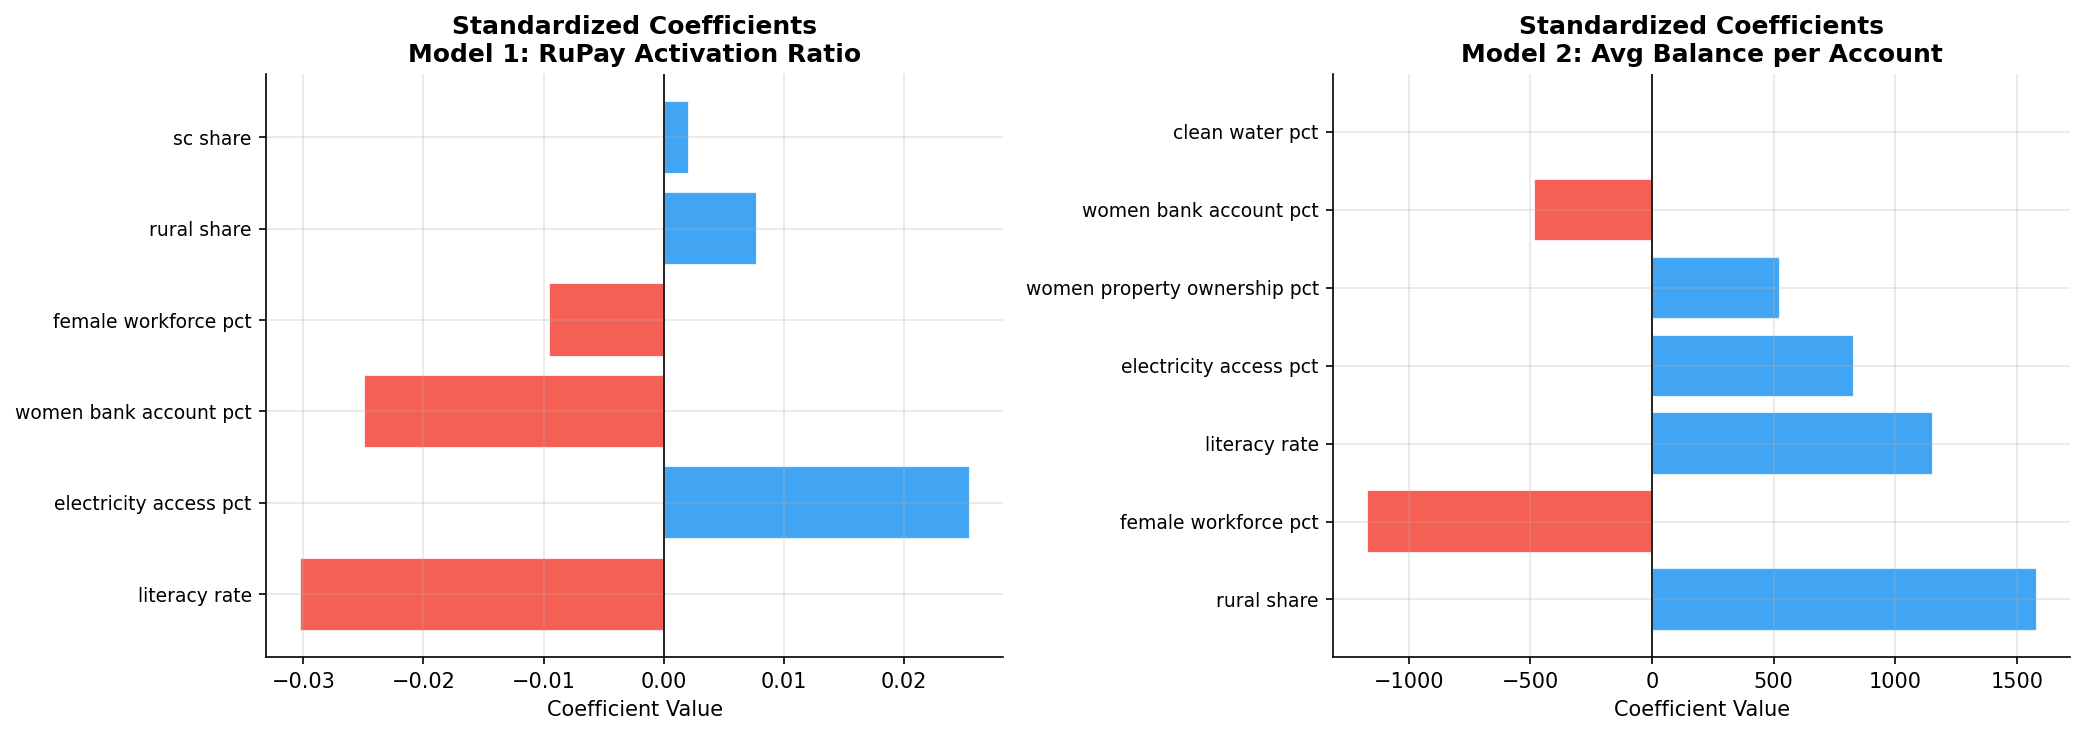

Saved: 04_regression_coefficients.png


In [13]:
reg_features_1 = [
    'literacy_rate', 'rural_share', 'women_bank_account_pct',
    'electricity_access_pct', 'female_workforce_pct', 'sc_share'
]
reg_features_1 = [f for f in reg_features_1 if f in df_state.columns]
 
reg_df1 = df_state[['rupay_activation_ratio'] + reg_features_1].dropna()
X1 = reg_df1[reg_features_1]
y1 = reg_df1['rupay_activation_ratio']
 
# Standardize features
scaler1 = StandardScaler()
X1_scaled = scaler1.fit_transform(X1)
 
model1 = LinearRegression()
model1.fit(X1_scaled, y1)
r2_1 = model1.score(X1_scaled, y1)
 
# Cross-validated R²
cv_scores1 = cross_val_score(model1, X1_scaled, y1, cv=5, scoring='r2')
 
print(f"\nModel 1: Predicting RuPay Activation Ratio")
print(f"R² = {r2_1:.3f} | CV R² = {cv_scores1.mean():.3f} ± {cv_scores1.std():.3f}")
print(f"\nCoefficients (standardized — larger abs value = more influence):")
coef_df1 = pd.DataFrame({
    'Feature': reg_features_1,
    'Coefficient': model1.coef_
}).sort_values('Coefficient', key=abs, ascending=False)
print(coef_df1.round(4).to_string(index=False))
 
# ── Model 2: Predicting Avg Balance per Account ─────────────
reg_features_2 = [
    'literacy_rate', 'rural_share', 'women_bank_account_pct',
    'electricity_access_pct', 'female_workforce_pct',
    'women_property_ownership_pct', 'clean_water_pct'
]
reg_features_2 = [f for f in reg_features_2 if f in df_state.columns]
 
reg_df2 = df_state[['avg_balance_per_account'] + reg_features_2].dropna()
X2 = reg_df2[reg_features_2]
y2 = reg_df2['avg_balance_per_account']
 
scaler2 = StandardScaler()
X2_scaled = scaler2.fit_transform(X2)
 
model2 = LinearRegression()
model2.fit(X2_scaled, y2)
r2_2 = model2.score(X2_scaled, y2)
cv_scores2 = cross_val_score(model2, X2_scaled, y2, cv=5, scoring='r2')
 
print(f"\nModel 2: Predicting Avg Balance per Account")
print(f"R² = {r2_2:.3f} | CV R² = {cv_scores2.mean():.3f} ± {cv_scores2.std():.3f}")
coef_df2 = pd.DataFrame({
    'Feature': reg_features_2,
    'Coefficient': model2.coef_
}).sort_values('Coefficient', key=abs, ascending=False)
print(coef_df2.round(4).to_string(index=False))
 
# ── Plot: Coefficient importance ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
for ax, coef_df, title in zip(axes,
    [coef_df1, coef_df2],
    ['Model 1: RuPay Activation Ratio', 'Model 2: Avg Balance per Account']):
 
    colors_bar = ['#2196F3' if c > 0 else '#F44336' for c in coef_df['Coefficient']]
    ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors_bar, alpha=0.85, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'Standardized Coefficients\n{title}', fontweight='bold')
    ax.set_xlabel('Coefficient Value')
    ax.set_yticklabels([f.replace('_', ' ') for f in coef_df['Feature']], fontsize=9)
 
plt.tight_layout()
plt.savefig(r"C:\Users\Mihika\Desktop\dsm_project_final\dsm project\results\visualisations\04_regression_coefficients.png", bbox_inches='tight')
plt.show()
print("Saved: 04_regression_coefficients.png")

Random Forest R² = 0.852
CV R² = -0.222 ± 0.314


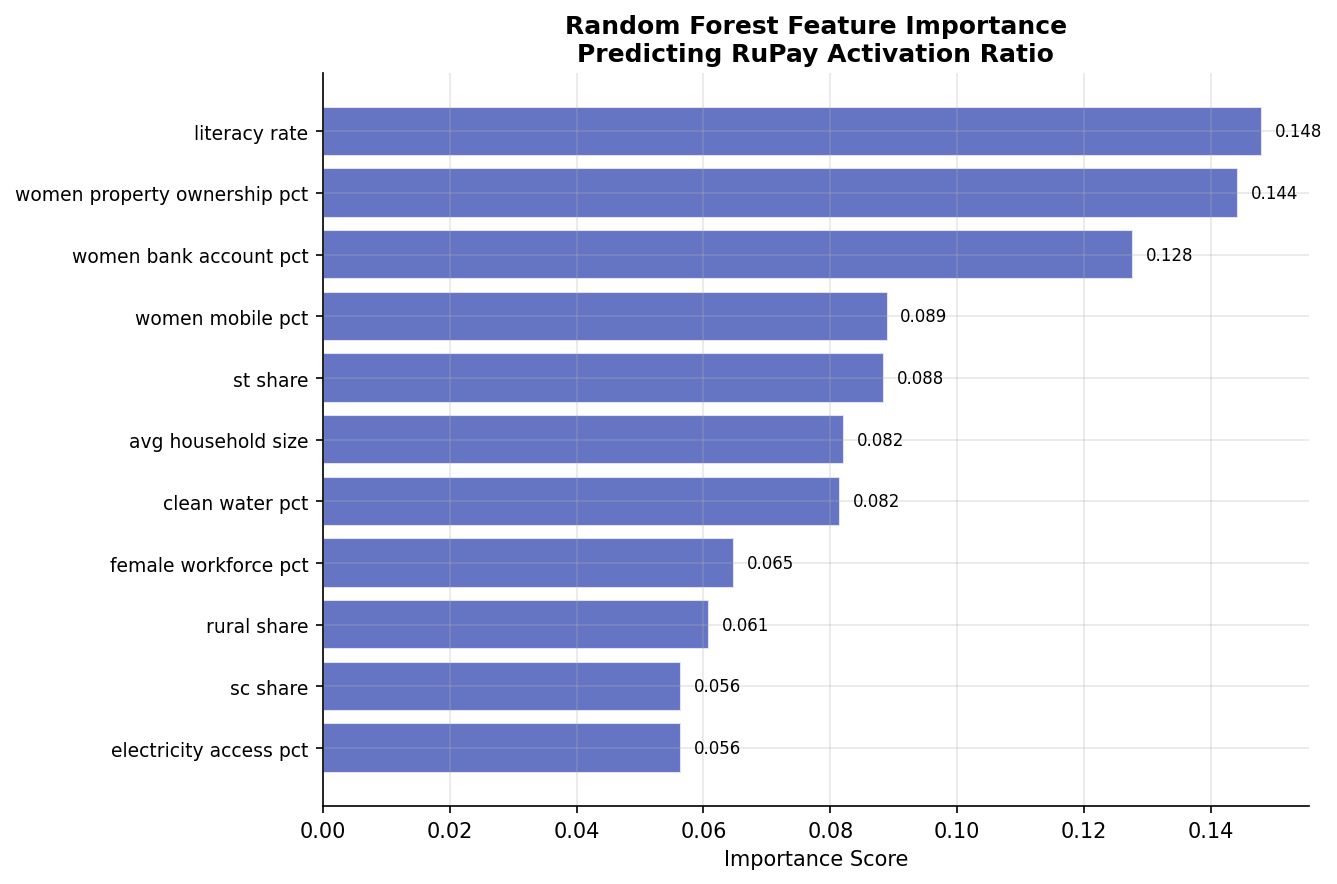

Saved: 05_random_forest_importance.png


In [15]:
rf_features = [
    'literacy_rate', 'rural_share', 'women_bank_account_pct',
    'electricity_access_pct', 'female_workforce_pct', 'sc_share',
    'st_share', 'avg_household_size', 'women_mobile_pct',
    'clean_water_pct', 'women_property_ownership_pct'
]
rf_features = [f for f in rf_features if f in df_state.columns]
 
rf_df = df_state[['rupay_activation_ratio'] + rf_features].dropna()
X_rf = rf_df[rf_features]
y_rf = rf_df['rupay_activation_ratio']
 
rf_model = RandomForestRegressor(n_estimators=500, random_state=42, max_features='sqrt')
rf_model.fit(X_rf, y_rf)
rf_r2 = rf_model.score(X_rf, y_rf)
rf_cv = cross_val_score(rf_model, X_rf, y_rf, cv=5, scoring='r2')
 
print(f"Random Forest R² = {rf_r2:.3f}")
print(f"CV R² = {rf_cv.mean():.3f} ± {rf_cv.std():.3f}")
 
importance_df = pd.DataFrame({
    'Feature': rf_features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)
 
fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(importance_df['Feature'], importance_df['Importance'],
               color='#3F51B5', alpha=0.8, edgecolor='white')
ax.set_title('Random Forest Feature Importance\nPredicting RuPay Activation Ratio',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Importance Score')
ax.set_yticklabels([f.replace('_', ' ') for f in importance_df['Feature']], fontsize=9)
 
# Add value labels
for bar, val in zip(bars, importance_df['Importance']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8)
 
plt.tight_layout()
plt.savefig(r"C:\Users\Mihika\Desktop\dsm_project_final\dsm project\results\visualisations\05_random_forest_importance.png", bbox_inches='tight')
plt.show()
print("Saved: 05_random_forest_importance.png")

In [16]:
print(df_state[df_state['women_bank_account_pct'] < 0][['state_name', 'women_bank_account_pct']])

  state_name  women_bank_account_pct
7      Delhi                   -6.25


In [17]:
df_state['women_bank_account_pct'] = df_state['women_bank_account_pct'].apply(
    lambda x: np.nan if x < 0 else x
)

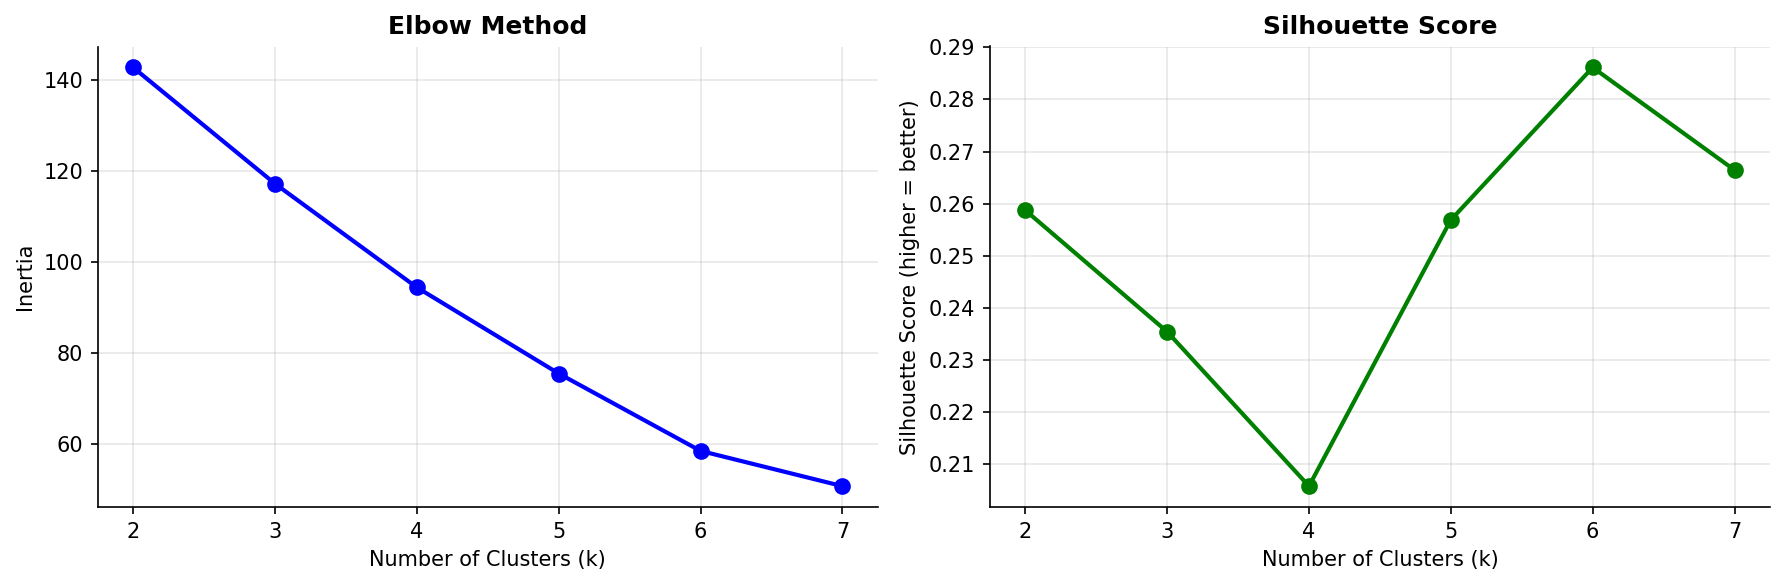

Best k by silhouette: k=6


In [19]:
cluster_features = [
    'rupay_activation_ratio', 'avg_balance_per_account',
    'accounts_per_capita', 'women_bank_account_pct',
    'literacy_rate', 'rural_share'
]
cluster_features = [f for f in cluster_features if f in df_state.columns]
 
cluster_df = df_state[['state_name', 'Name Of The Region'] + cluster_features].dropna()
X_clust = cluster_df[cluster_features]
scaler_c = StandardScaler()
X_clust_scaled = scaler_c.fit_transform(X_clust)
 
# Elbow method — find optimal k
inertias = []
sil_scores = []
K_range = range(2, 8)
 
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_clust_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_clust_scaled, km.labels_))
 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=7)
axes[0].set_title('Elbow Method', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
 
axes[1].plot(K_range, sil_scores, 'go-', linewidth=2, markersize=7)
axes[1].set_title('Silhouette Score', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score (higher = better)')
 
plt.tight_layout()
plt.savefig(r"C:\Users\Mihika\Desktop\dsm_project_final\dsm project\results\visualisations\06_elbow_silhouette.png", bbox_inches='tight')
plt.show()
print(f"Best k by silhouette: k={K_range[np.argmax(sil_scores)]}")

In [20]:
best_k = 6
km_final = KMeans(n_clusters=6, random_state=42, n_init=10)
cluster_df = cluster_df.copy()
cluster_df['cluster'] = km_final.fit_predict(X_clust_scaled)

# Label clusters by average RuPay ratio (highest to lowest)
cluster_means = cluster_df.groupby('cluster')['rupay_activation_ratio'].mean().sort_values(ascending=False)
label_map = {
    cluster_means.index[0]: 'Tier 1 — High Inclusion',
    cluster_means.index[1]: 'Tier 2 — Above Average',
    cluster_means.index[2]: 'Tier 3 — Moderate',
    cluster_means.index[3]: 'Tier 4 — Below Average',
    cluster_means.index[4]: 'Tier 5 — Poor Inclusion',
    cluster_means.index[5]: 'Tier 6 — Nominal Inclusion'
}
cluster_df['inclusion_tier'] = cluster_df['cluster'].map(label_map)
 
print("\nCluster Assignment:")
print(cluster_df[['state_name', 'inclusion_tier',
                   'rupay_activation_ratio', 'avg_balance_per_account',
                   'women_bank_account_pct']].sort_values('inclusion_tier').to_string(index=False))
 
print("\nCluster Means:")
print(cluster_df.groupby('inclusion_tier')[cluster_features].mean().round(3).to_string())


Cluster Assignment:
       state_name             inclusion_tier  rupay_activation_ratio  avg_balance_per_account  women_bank_account_pct
      Lakshadweep    Tier 1 — High Inclusion                0.751521             19380.207846                   66.95
          Haryana     Tier 2 — Above Average                0.692925              6927.443716                   74.35
      Uttarakhand     Tier 2 — Above Average                0.675965              7322.421907                   80.55
         Nagaland     Tier 2 — Above Average                0.758412              3746.899829                   66.65
      Maharashtra     Tier 2 — Above Average                0.712835              5703.369815                   72.95
          Gujarat     Tier 2 — Above Average                0.764111              6347.848821                   70.50
          Manipur     Tier 2 — Above Average                0.660017              2953.101578                   74.65
           Punjab     Tier 2 — Abov

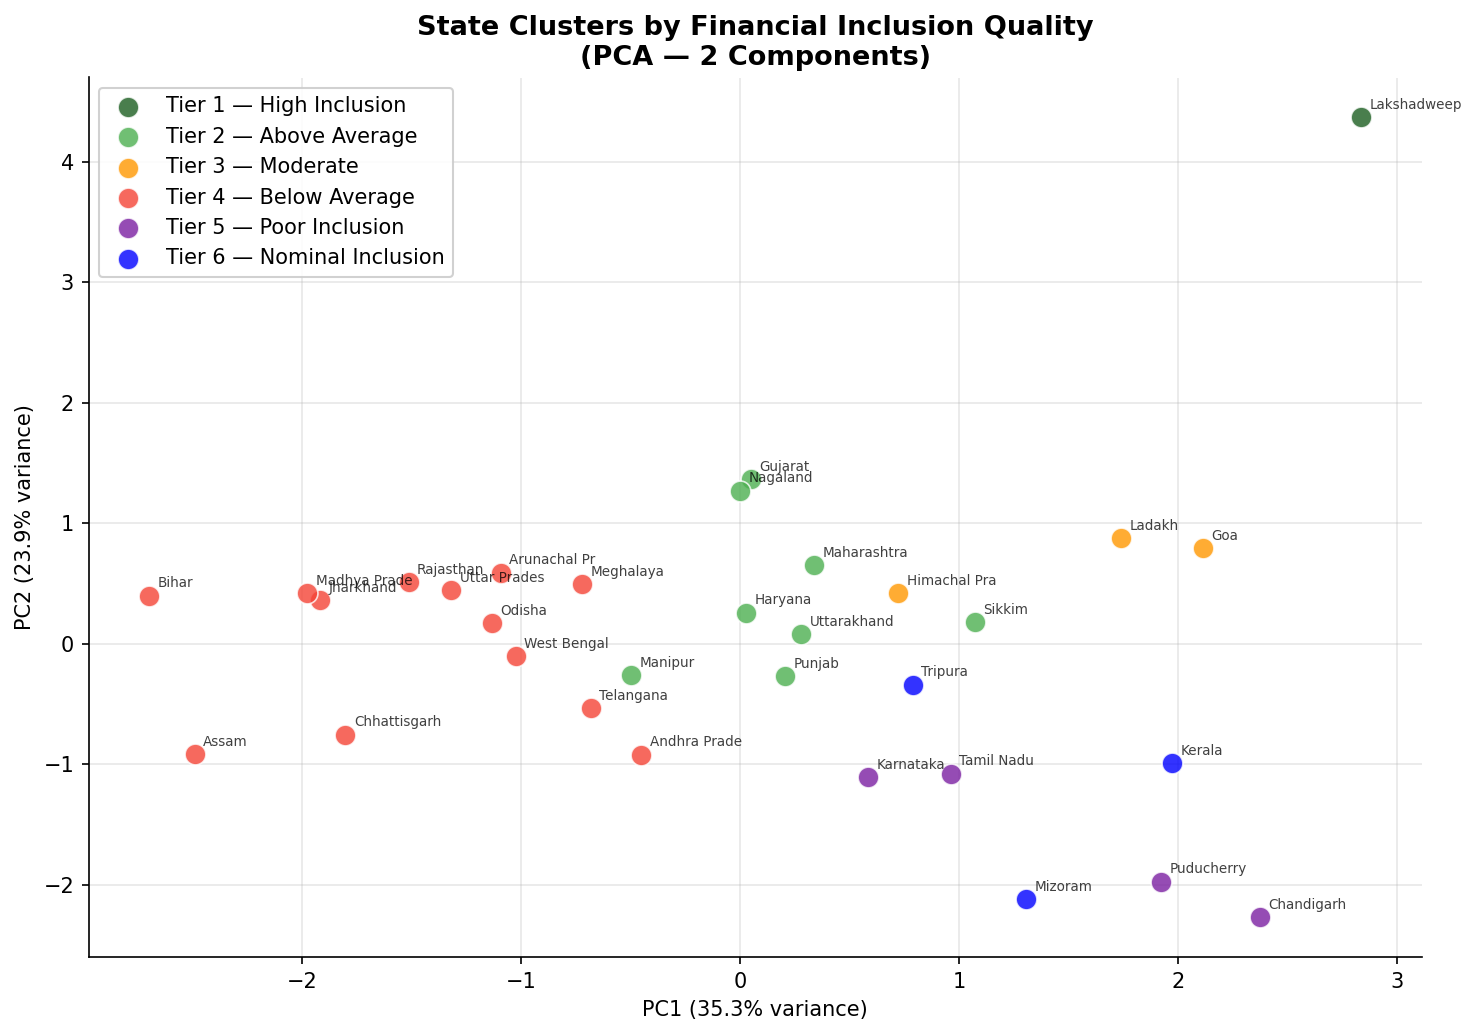

Saved: 07_kmeans_pca.png


In [22]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_clust_scaled)
cluster_df['pca1'] = X_pca[:, 0]
cluster_df['pca2'] = X_pca[:, 1]
 
tier_colors = {
    'Tier 1 — High Inclusion':    '#1B5E20',
    'Tier 2 — Above Average':     '#4CAF50',
    'Tier 3 — Moderate':          '#FF9800',
    'Tier 4 — Below Average':     '#F44336',
    'Tier 5 — Poor Inclusion': '#7B1FA2',
    'Tier 6 — Nominal Inclusion':    '#0000FF'
} 
fig, ax = plt.subplots(figsize=(10, 7))
for tier, grp in cluster_df.groupby('inclusion_tier'):
    ax.scatter(grp['pca1'], grp['pca2'], label=tier,
               color=tier_colors[tier], s=100, alpha=0.8,
               edgecolors='white', linewidth=0.8, zorder=3)
    for _, row in grp.iterrows():
        ax.annotate(row['state_name'][:12], (row['pca1'], row['pca2']),
                    fontsize=6.5, alpha=0.75, xytext=(4, 4),
                    textcoords='offset points')
 
ax.set_title('State Clusters by Financial Inclusion Quality\n(PCA — 2 Components)',
             fontsize=13, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=10)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=10)
ax.legend(fontsize=10, framealpha=0.9)
plt.tight_layout()
plt.savefig(r"C:\Users\Mihika\Desktop\dsm_project_final\dsm project\results\visualisations\07_kmeans_pca.png", bbox_inches='tight')
plt.show()
print("Saved: 07_kmeans_pca.png")

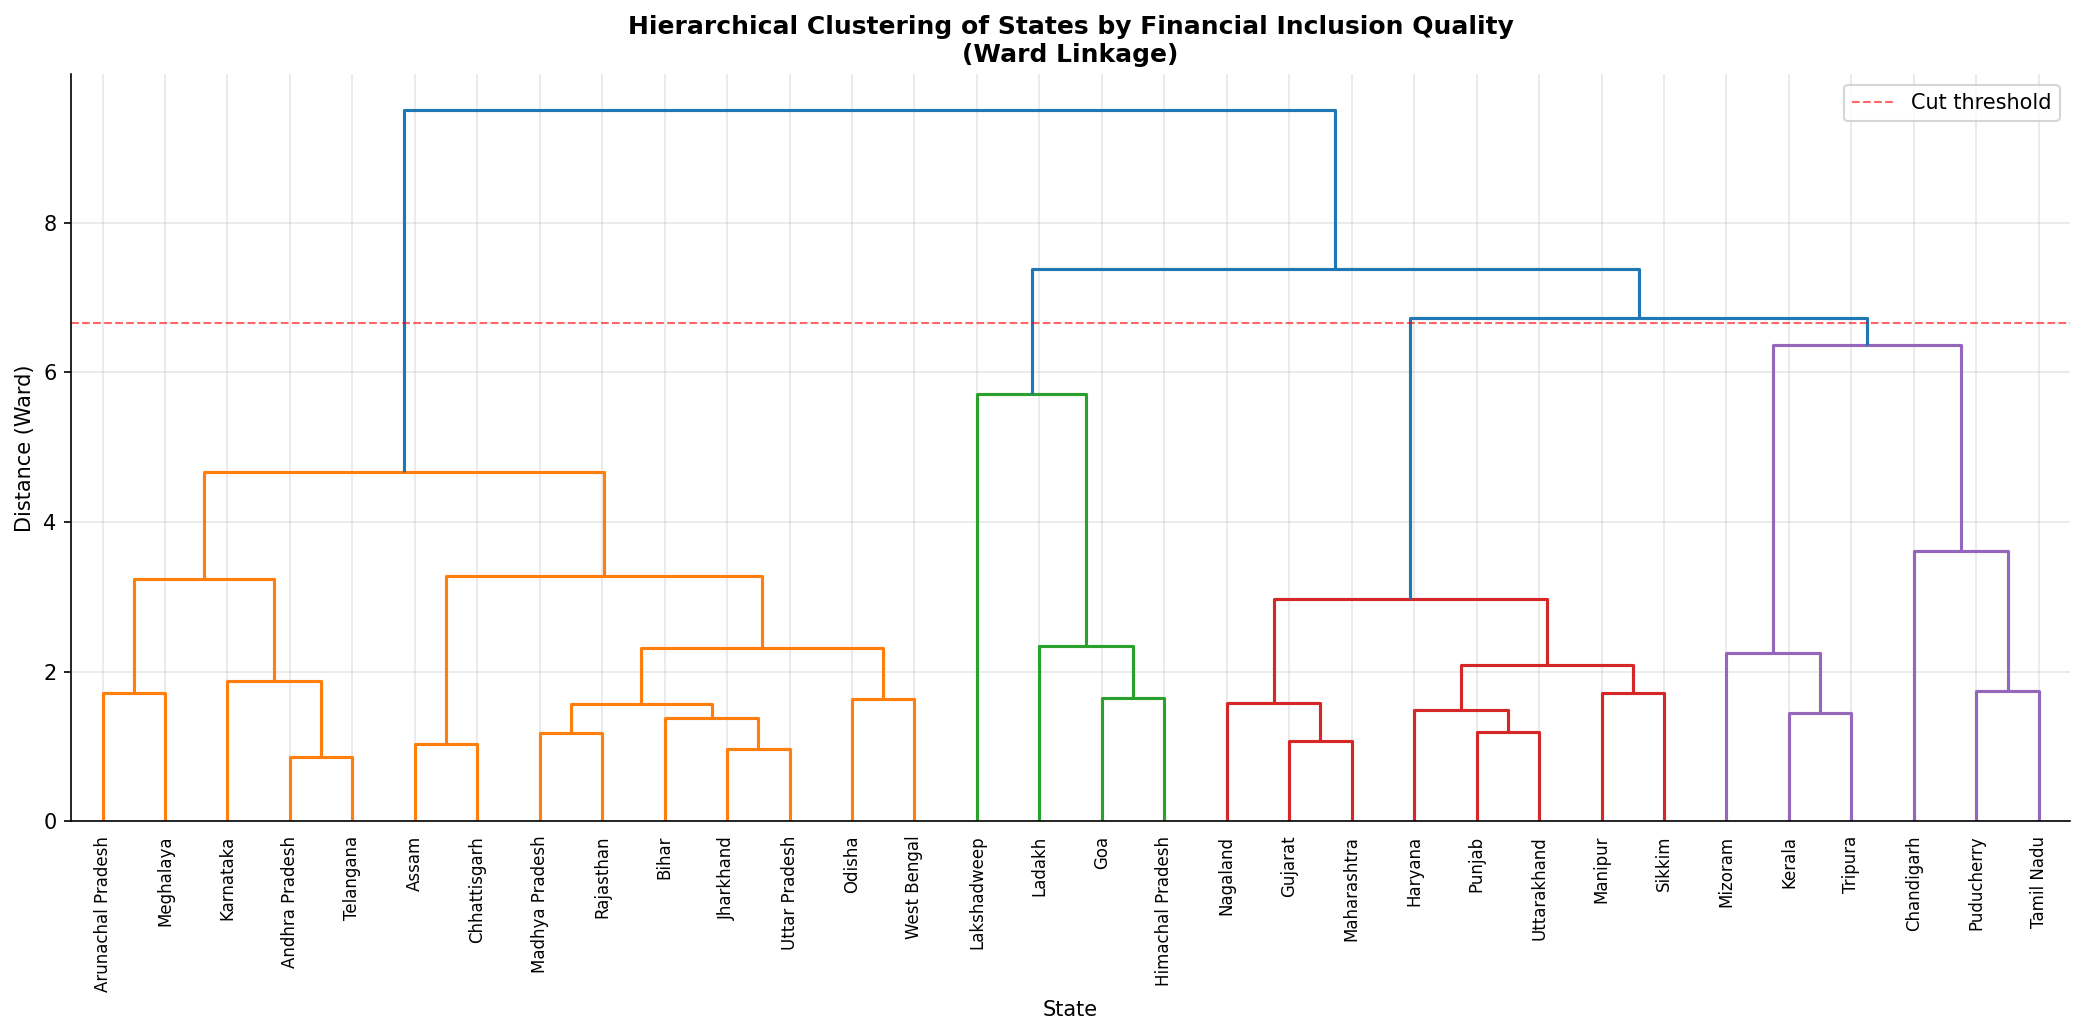


Hierarchical k=3:
         rupay_activation_ratio  avg_balance_per_account  accounts_per_capita  women_bank_account_pct  literacy_rate  rural_share
hier_k3                                                                                                                          
1                         0.676                 5197.883                0.535                  80.254         59.406        0.831
2                         0.703                12406.230                0.173                  82.288         75.115        0.859
3                         0.662                 5437.145                0.314                  78.975         72.267        0.644

Hierarchical k=4:
         rupay_activation_ratio  avg_balance_per_account  accounts_per_capita  women_bank_account_pct  literacy_rate  rural_share
hier_k4                                                                                                                          
1                         0.676                 5197

In [25]:
# ============================================================
# CELL 7B — HIERARCHICAL CLUSTERING (BETTER FOR 36 STATES)
# ============================================================
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist

# Use same scaled data from Cell 7
Z = linkage(X_clust_scaled, method='ward')
# Ward minimizes within-cluster variance — best for your use case

fig, ax = plt.subplots(figsize=(14, 7))
dendrogram(
    Z,
    labels=cluster_df['state_name'].values,
    leaf_rotation=90,
    leaf_font_size=8,
    color_threshold=0.7 * max(Z[:, 2]),
    ax=ax
)
ax.set_title('Hierarchical Clustering of States by Financial Inclusion Quality\n(Ward Linkage)',
             fontweight='bold', fontsize=12)
ax.set_xlabel('State')
ax.set_ylabel('Distance (Ward)')
ax.axhline(y=0.7 * max(Z[:, 2]), color='red', linestyle='--',
           linewidth=1, alpha=0.6, label='Cut threshold')
ax.legend()
plt.tight_layout()
plt.savefig(r"C:\Users\Mihika\Desktop\dsm_project_final\dsm project\results\visualisations\07b_dendrogram.png", bbox_inches='tight')
plt.show()

# ── Cut tree into clusters and compare with K-means ─────────
# Try k=3 and k=5 and see which makes more interpretive sense
for k in [3, 4, 5]:
    cluster_df[f'hier_k{k}'] = fcluster(Z, k, criterion='maxclust')
    print(f"\nHierarchical k={k}:")
    print(cluster_df.groupby(f'hier_k{k}')[cluster_features].mean().round(3).to_string())

# ── Agreement between K-means and Hierarchical ──────────────
from sklearn.metrics import adjusted_rand_score
for k in [3, 4, 5]:
    ari = adjusted_rand_score(cluster_df['cluster'], cluster_df[f'hier_k{k}'])
    print(f"Agreement (ARI) between K-means and Hierarchical k={k}: {ari:.3f}")
    # ARI > 0.7 means strong agreement — both methods are telling you the same story

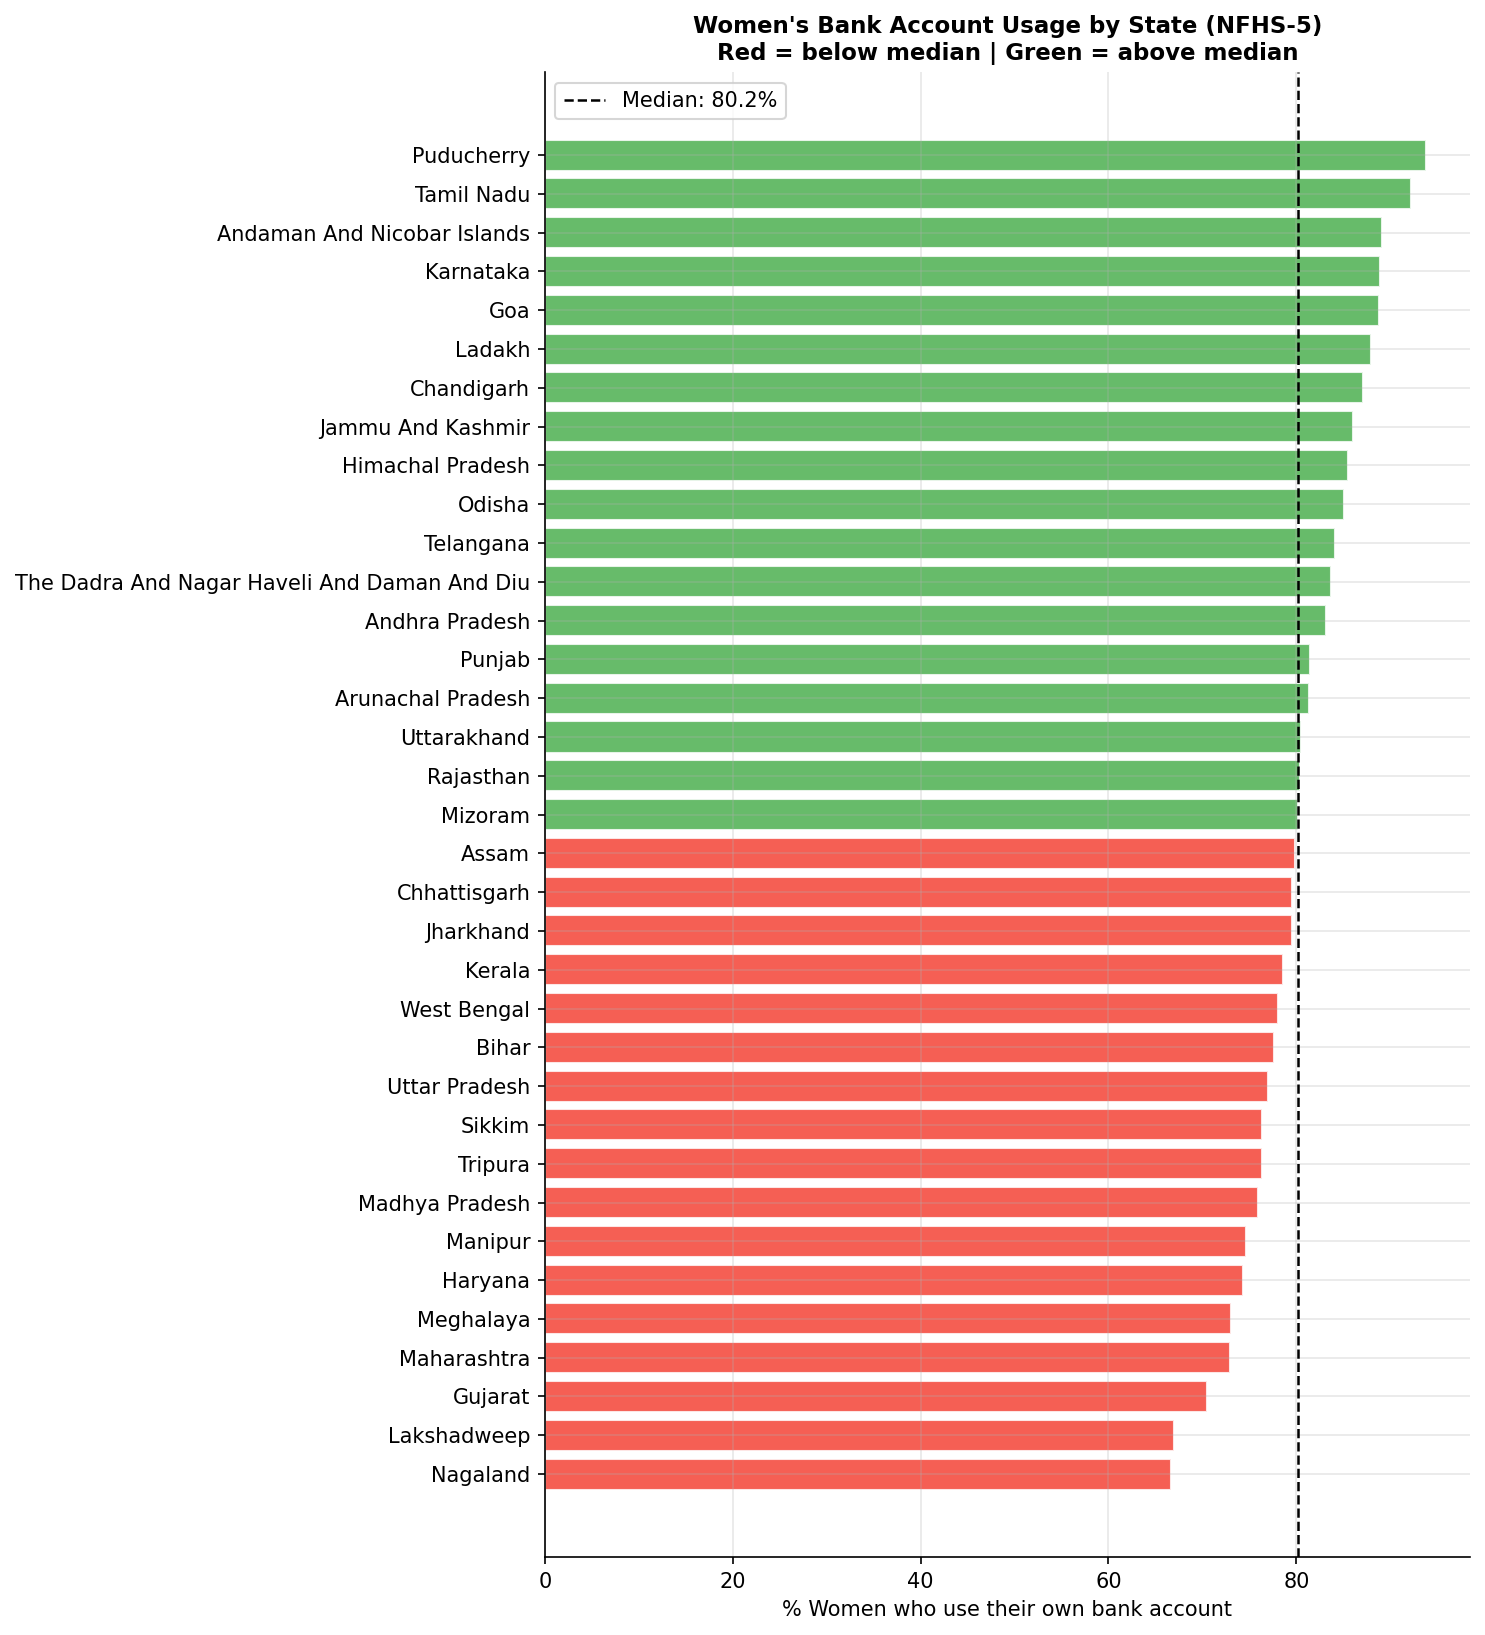

Saved: 08_gender_account_usage.png


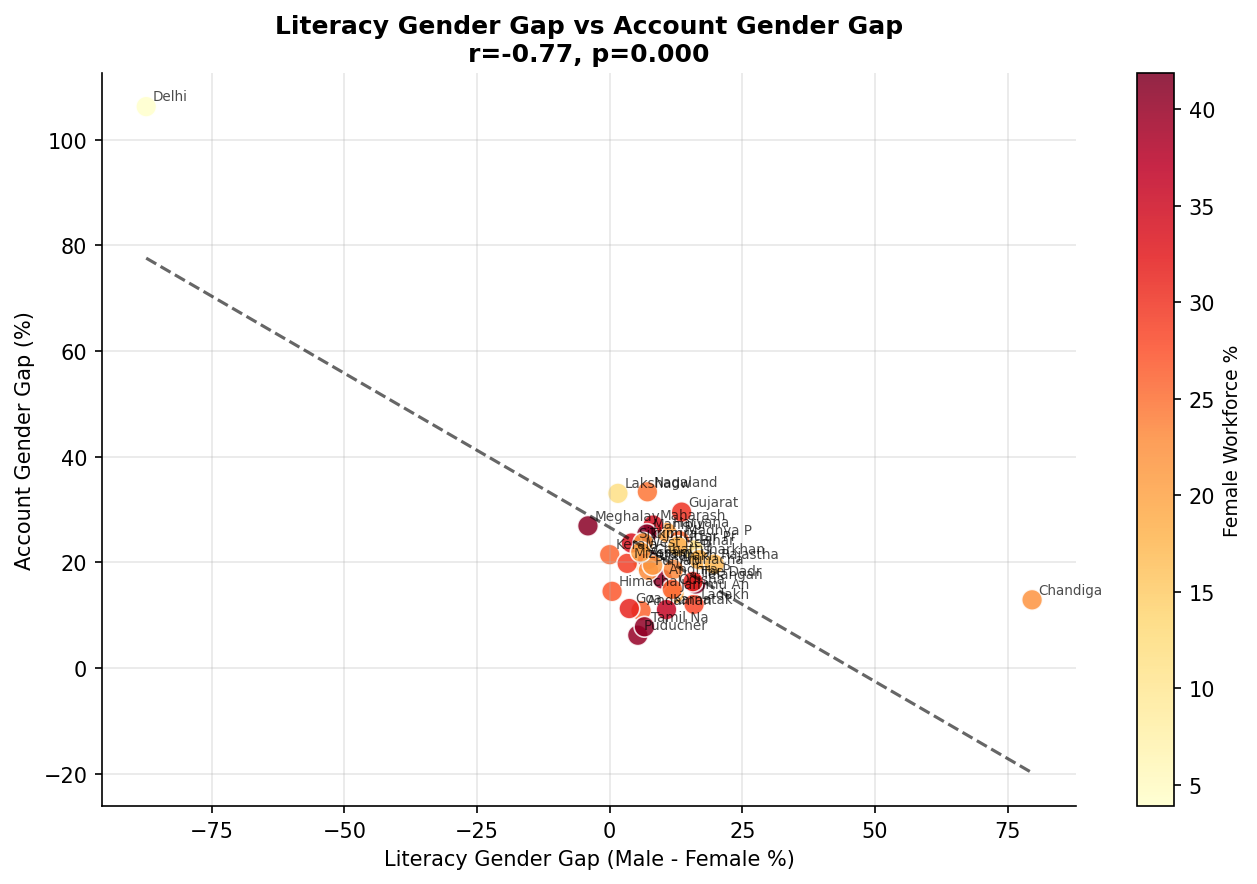

Saved: 09_gender_gap_scatter.png


In [28]:
if 'women_bank_account_pct' in df_state.columns:
    gender_df = df_state[['state_name', 'women_bank_account_pct',
                           'literacy_gender_gap', 'account_gender_gap',
                           'female_workforce_pct_nfhs']].dropna(
                               subset=['women_bank_account_pct']).sort_values(
                                   'women_bank_account_pct')
 
    fig, ax = plt.subplots(figsize=(10, 11))
    colors_bar = ['#F44336' if v < gender_df['women_bank_account_pct'].median()
                  else '#4CAF50' for v in gender_df['women_bank_account_pct']]
    ax.barh(gender_df['state_name'], gender_df['women_bank_account_pct'],
            color=colors_bar, alpha=0.85, edgecolor='white')
    ax.axvline(gender_df['women_bank_account_pct'].median(),
               color='black', linestyle='--', linewidth=1.2,
               label=f"Median: {gender_df['women_bank_account_pct'].median():.1f}%")
    ax.set_title("Women's Bank Account Usage by State (NFHS-5)\n"
                 "Red = below median | Green = above median",
                 fontweight='bold', fontsize=11)
    ax.set_xlabel("% Women who use their own bank account")
    ax.legend()
    plt.tight_layout()
    plt.savefig(r"C:\Users\Mihika\Desktop\dsm_project_final\dsm project\results\visualisations\08_gender_account_usage.png", bbox_inches='tight')
    plt.show()
    print("Saved: 08_gender_account_usage.png")
 
# ── Gender gap vs literacy gender gap ───────────────────────
if 'account_gender_gap' in df_state.columns and 'literacy_gender_gap' in df_state.columns:
    gg_df = df_state[['state_name', 'account_gender_gap', 'literacy_gender_gap',
                       'female_workforce_pct_nfhs']].dropna()
 
    fig, ax = plt.subplots(figsize=(9, 6))
    sc = ax.scatter(gg_df['literacy_gender_gap'], gg_df['account_gender_gap'],
                    c=gg_df['female_workforce_pct_nfhs'] if 'female_workforce_pct_nfhs' in gg_df.columns else '#9C27B0',
                    cmap='YlOrRd', s=100, alpha=0.85, edgecolors='white', linewidth=0.8)
 
    if 'female_workforce_pct_nfhs' in gg_df.columns:
        cbar = plt.colorbar(sc)
        cbar.set_label('Female Workforce %', fontsize=9)
 
    m, b, r, p, _ = stats.linregress(gg_df['literacy_gender_gap'], gg_df['account_gender_gap'])
    x_line = np.linspace(gg_df['literacy_gender_gap'].min(),
                         gg_df['literacy_gender_gap'].max(), 100)
    ax.plot(x_line, m * x_line + b, 'k--', linewidth=1.5, alpha=0.6)
    ax.set_title(f'Literacy Gender Gap vs Account Gender Gap\nr={r:.2f}, p={p:.3f}',
                 fontweight='bold')
    ax.set_xlabel('Literacy Gender Gap (Male - Female %)')
    ax.set_ylabel('Account Gender Gap (%)')
 
    for _, row in gg_df.iterrows():
        ax.annotate(row['state_name'][:8], (row['literacy_gender_gap'], row['account_gender_gap']),
                    fontsize=6.5, alpha=0.7, xytext=(3, 3), textcoords='offset points')
 
    plt.tight_layout()
    plt.savefig(r"C:\Users\Mihika\Desktop\dsm_project_final\dsm project\results\visualisations\09_gender_gap_scatter.png", bbox_inches='tight')
    plt.show()
    print("Saved: 09_gender_gap_scatter.png")
 

In [29]:
nfhs_raw = pd.read_csv('data/raw/NFHS.csv')
print(f"Shape: {df_full.shape}")

 

Shape: (36, 56)



States with complete NFHS-4 and NFHS-5 data: 36

Average change across all states (pp = percentage points):
  women_bank_pct            +20.46 pp
  women_mobile_pct          +9.94 pp
  female_workforce_pct      +2.25 pp
  women_property_pct        +2.14 pp


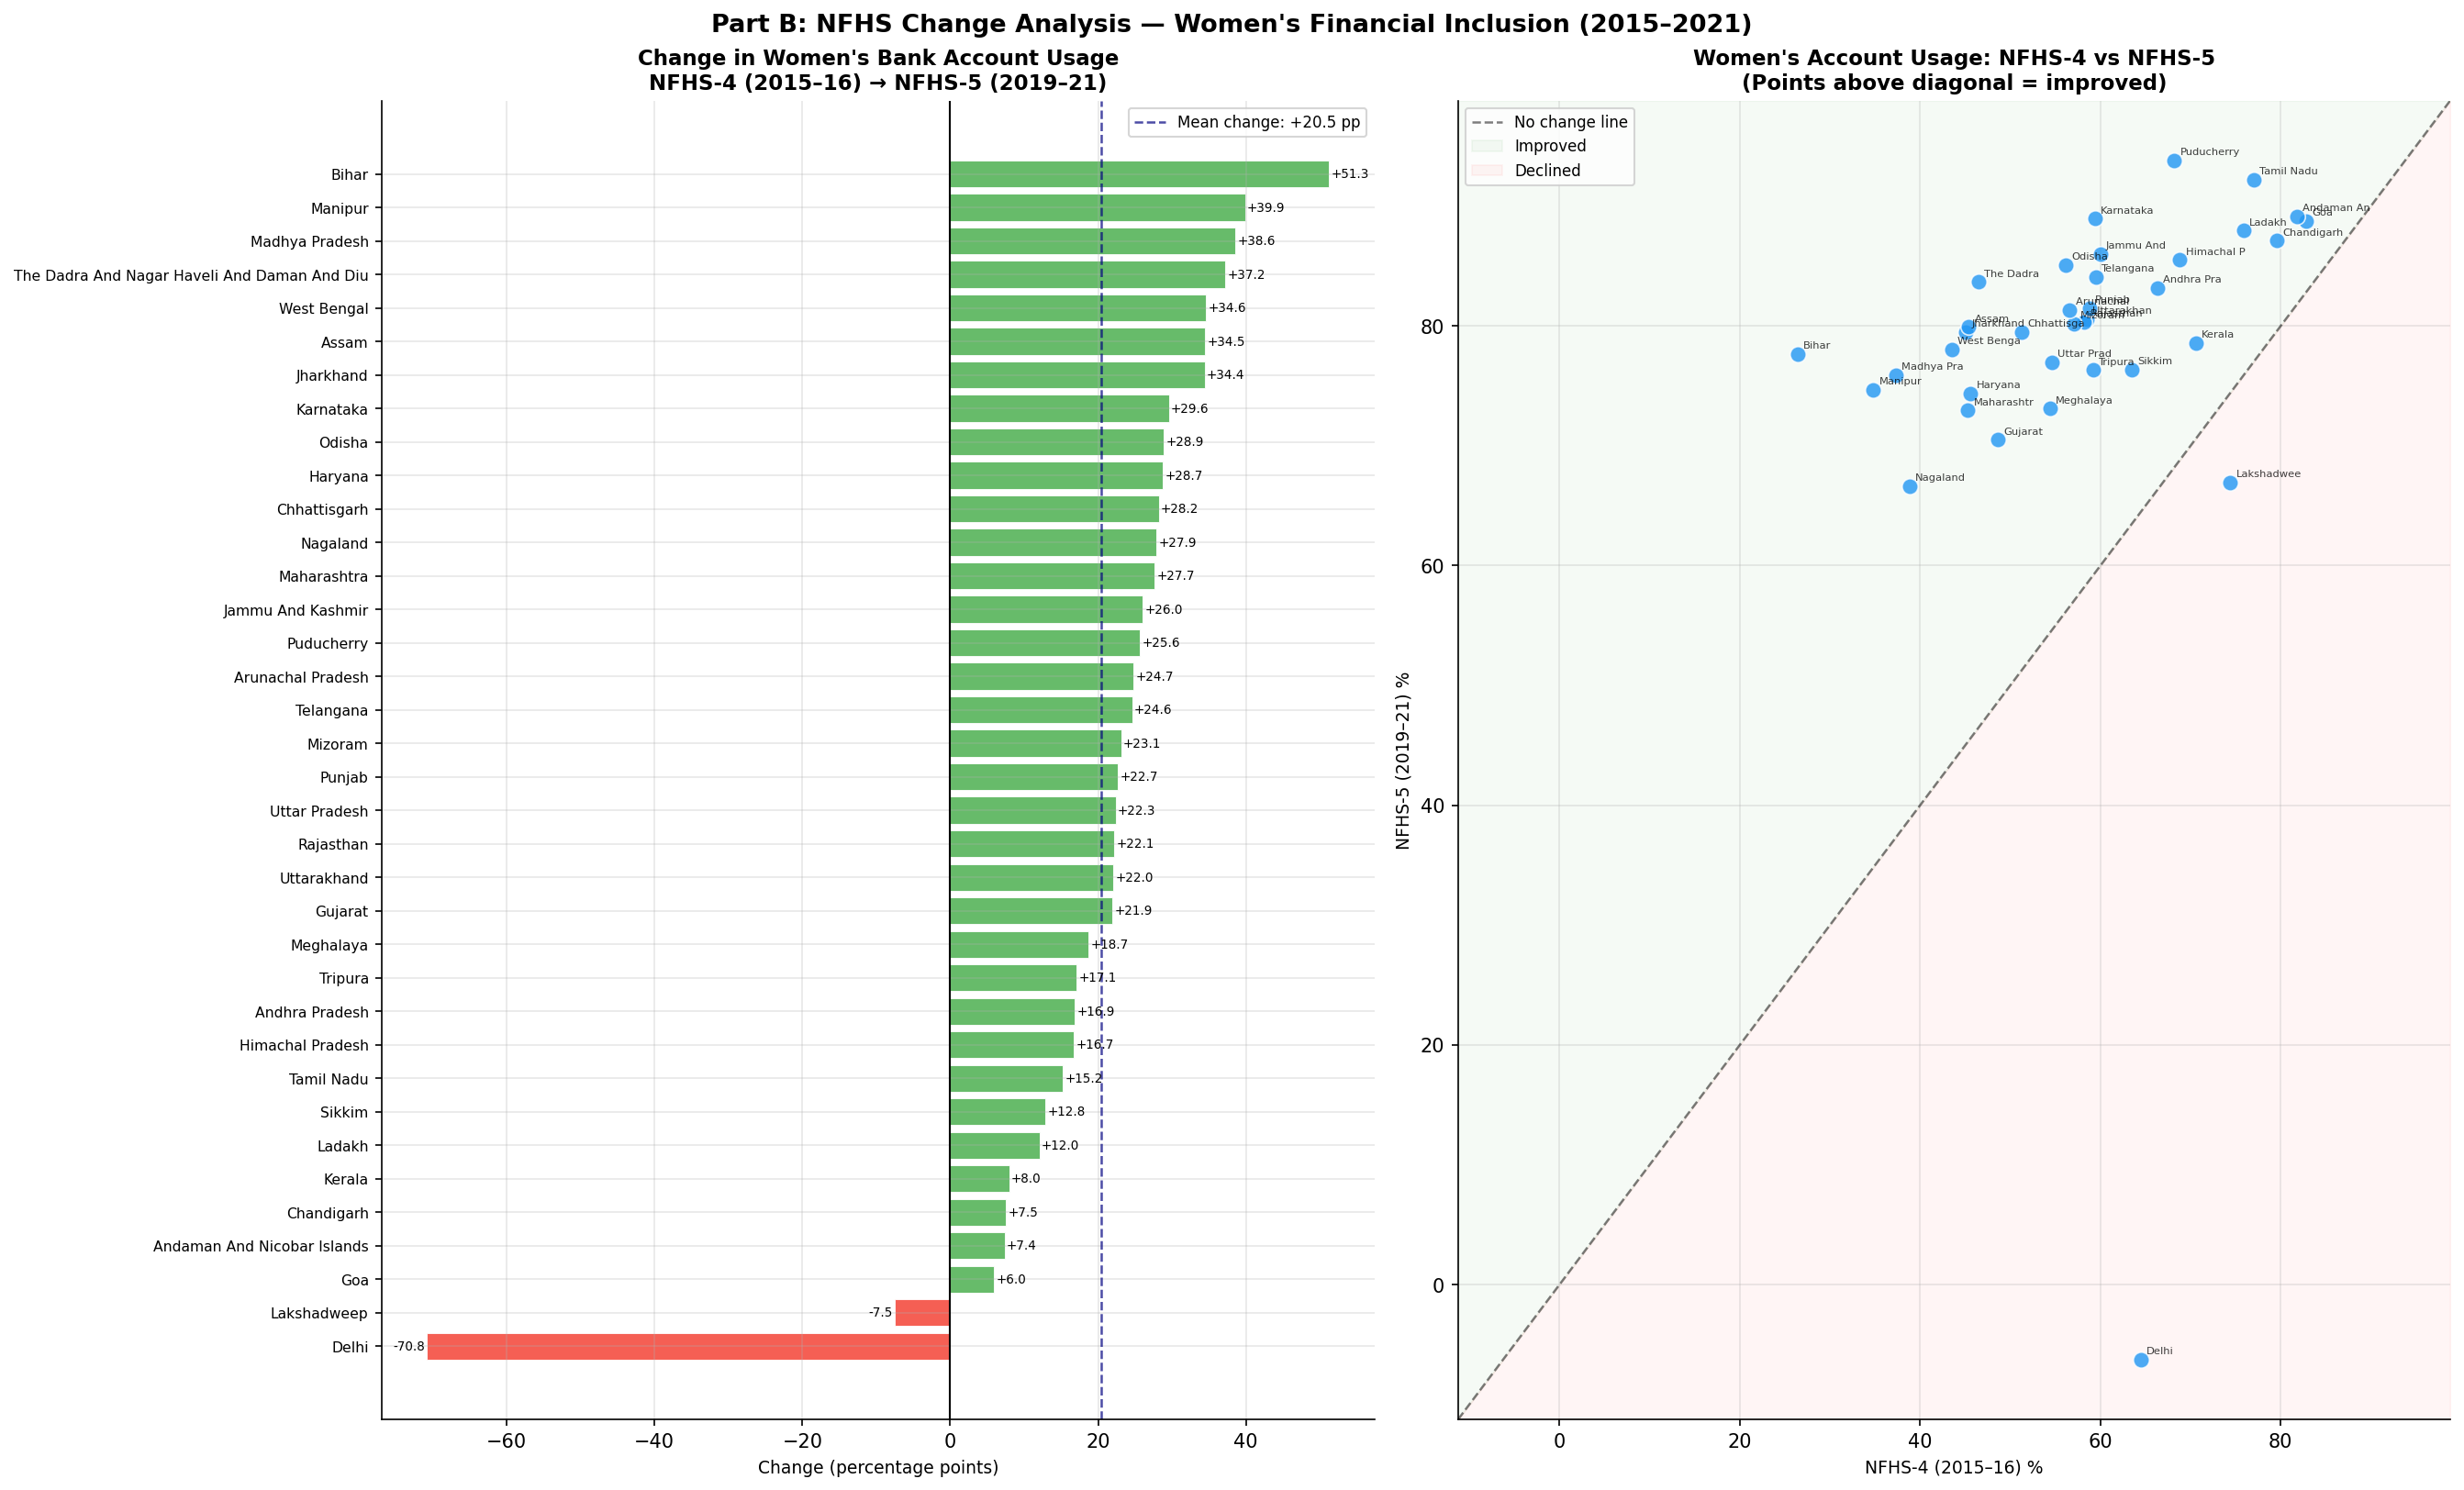

Saved: results/advanced/partB_nfhs_change.png


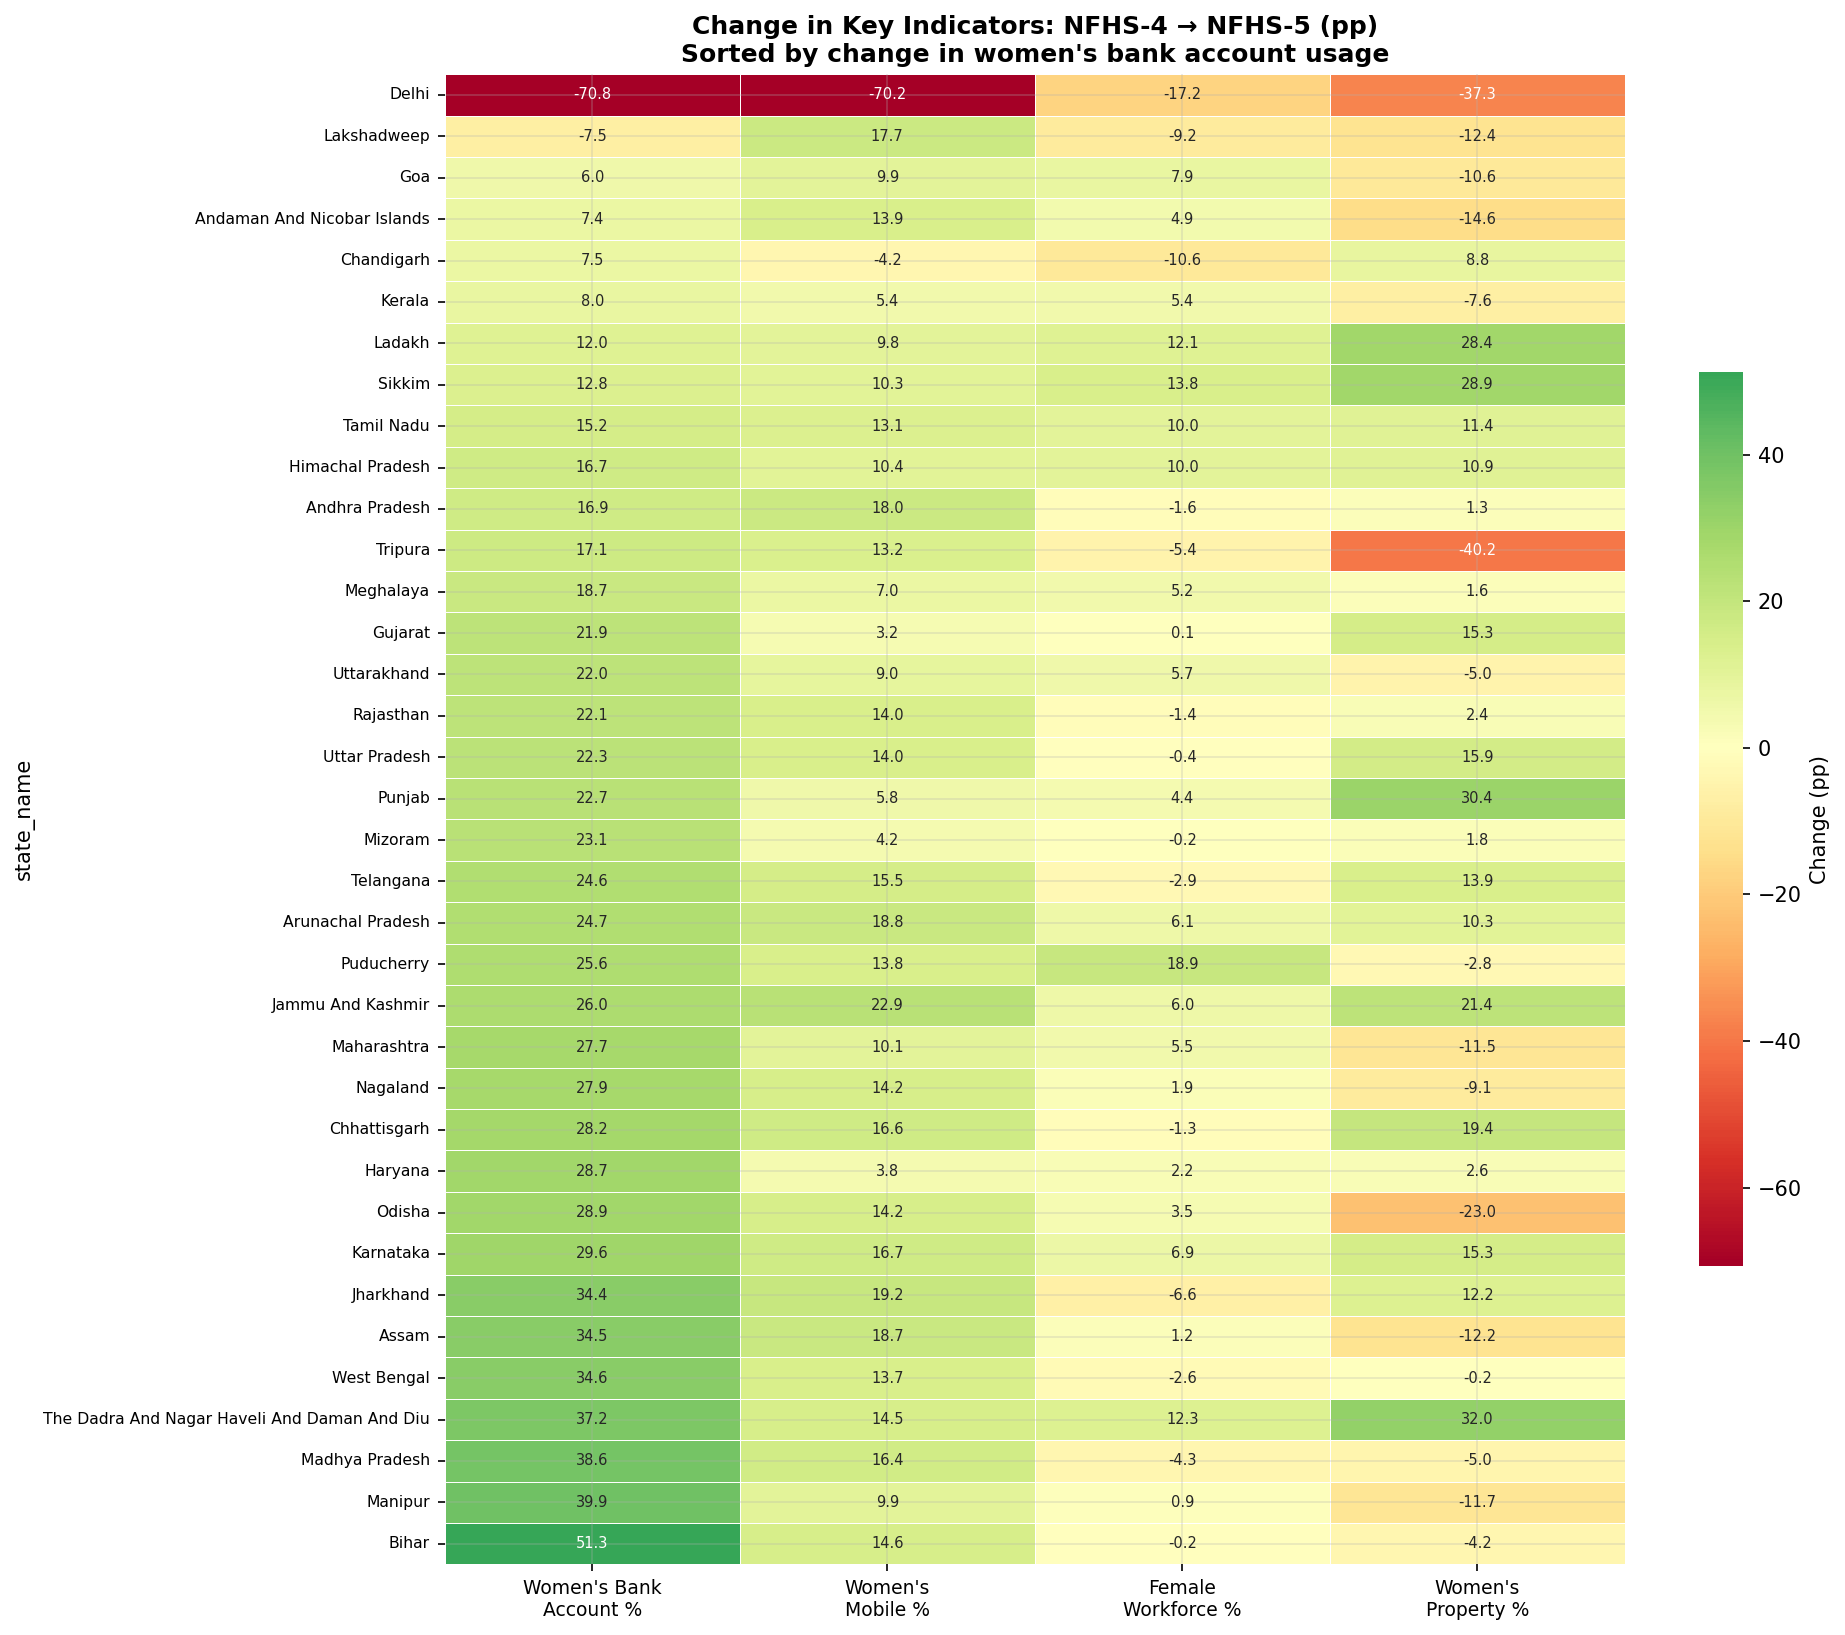

Saved: results/advanced/partB_nfhs_heatmap.png

--- Correlation: NFHS change vs current PMJDY quality ---
  women_bank_pct_change vs rupay_activation_ratio          r=-0.139  p=0.420 ns
  women_bank_pct_change vs avg_balance_per_account         r=-0.322  p=0.056 *
  women_bank_pct_change vs accounts_per_capita             r=+0.190  p=0.268 ns

Top 5 improvers (women's bank account usage):
                                  state_name  women_bank_pct_nfhs4  women_bank_pct_nfhs5  women_bank_pct_change
                                       Bihar                  26.4                  77.6                   51.3
                                     Manipur                  34.8                  74.6                   39.9
                              Madhya Pradesh                  37.3                  75.9                   38.6
The Dadra And Nagar Haveli And Daman And Diu                  46.5                  83.6                   37.2
                                 West Bengal    

In [30]:
# ── Column name constants ────────────────────────────────────
SURVEY_COL    = 'Nfhs Survey Number (Nfhs - 4 Or Nfhs - 5)'
RESIDENCE_COL = 'Residence Type'
STATE_COL     = 'State'

BANK_COL      = ('Women Having A Bank Or Savings Account That They '
                 'Themselves Use (%) (UOM:%(Percentage)), Scaling Factor:1')
FEM_LIT_COL   = ('Women Age Group 15 To 49 Years Who Are Literate '
                 '(%) (UOM:%(Percentage)), Scaling Factor:1')
MALE_LIT_COL  = ('Men Age Group 15 To 49 Years Who Are Literate '
                 '(%) (UOM:%(Percentage)), Scaling Factor:1')
MOBILE_COL    = ('Women Having A Mobile Phone That They Themselves '
                 'Use (%) (UOM:%(Percentage)), Scaling Factor:1')
WORKFORCE_COL = ('Women Who Worked In The Last 12 Months And Were '
                 'Paid In Cash (%) (UOM:%(Percentage)), Scaling Factor:1')
PROPERTY_COL  = ('Women Owning A House And Or Land (Alone Or Jointly '
                 'With Others) (%) (UOM:%(Percentage)), Scaling Factor:1')

TRACK_COLS = {
    'women_bank_pct'      : BANK_COL,
    'women_mobile_pct'    : MOBILE_COL,
    'female_workforce_pct': WORKFORCE_COL,
    'women_property_pct'  : PROPERTY_COL,
}
# Note: Female/male literacy dropped — NFHS-4 in your dataset does not
# contain literacy values for any state, so change cannot be computed.

# ── Step 1: Build per-round state-level tables ────────────────
# NFHS-4: already has 'Total' rows → one row per state
nfhs4 = nfhs_raw[nfhs_raw[SURVEY_COL] == 'NFHS-4'].copy()
nfhs4['state_name'] = nfhs4[STATE_COL].str.strip().str.title()
nfhs4_state = nfhs4[['state_name'] + list(TRACK_COLS.values())].copy()

# NFHS-5: has Rural + Urban rows → average them for state total
nfhs5 = nfhs_raw[nfhs_raw[SURVEY_COL] == 'NFHS-5'].copy()
nfhs5['state_name'] = nfhs5[STATE_COL].str.strip().str.title()
nfhs5_state = (nfhs5
               .groupby('state_name')[list(TRACK_COLS.values())]
               .mean()
               .reset_index())

# ── Step 2: Merge on state_name, THEN rename ─────────────────
# Rename BEFORE merge causes pandas to append the original long
# column name as suffix instead of the short name. Fix: merge
# on original column names, then rename using suffix pattern.
change = nfhs4_state.merge(
    nfhs5_state, on='state_name', suffixes=('_nfhs4', '_nfhs5'))

# Now rename: long_col_name_nfhs4 → short_name_nfhs4
rename_map = {}
for short, long_col in TRACK_COLS.items():
    rename_map[f'{long_col}_nfhs4'] = f'{short}_nfhs4'
    rename_map[f'{long_col}_nfhs5'] = f'{short}_nfhs5'
change = change.rename(columns=rename_map)

# Compute change (NFHS-5 minus NFHS-4)
for var in TRACK_COLS.keys():
    change[f'{var}_change'] = change[f'{var}_nfhs5'] - change[f'{var}_nfhs4']

# Also bring in PMJDY rupay ratio for correlation
pmjdy_cols = ['state_name', 'rupay_activation_ratio',
              'avg_balance_per_account', 'rural_share', 'accounts_per_capita']
pmjdy_cols = [c for c in pmjdy_cols if c in df_state.columns]
change = change.merge(df_state[pmjdy_cols], on='state_name', how='left')

print(f"\nStates with complete NFHS-4 and NFHS-5 data: {len(change)}")
print("\nAverage change across all states (pp = percentage points):")
for var in TRACK_COLS.keys():
    col = f'{var}_change'
    if col in change.columns:
        mean_ch = change[col].mean()
        print(f"  {var:<25} {mean_ch:+.2f} pp")

# ── Step 3: Diverging bar chart — bank account usage change ──
bank_change = (change[['state_name', 'women_bank_pct_change',
                        'women_bank_pct_nfhs4', 'women_bank_pct_nfhs5']]
               .dropna()
               .sort_values('women_bank_pct_change'))

fig, axes = plt.subplots(1, 2, figsize=(18, 11))

# Left: diverging bar — change in women's bank account usage
bar_colors = ['#F44336' if v < 0 else '#4CAF50'
              for v in bank_change['women_bank_pct_change']]
axes[0].barh(bank_change['state_name'],
             bank_change['women_bank_pct_change'],
             color=bar_colors, alpha=0.85, edgecolor='white', linewidth=0.5)
axes[0].axvline(0, color='black', linewidth=1)
axes[0].axvline(bank_change['women_bank_pct_change'].mean(),
                color='navy', linewidth=1.2, linestyle='--', alpha=0.7,
                label=f"Mean change: "
                      f"{bank_change['women_bank_pct_change'].mean():+.1f} pp")
axes[0].set_title("Change in Women's Bank Account Usage\n"
                  "NFHS-4 (2015–16) → NFHS-5 (2019–21)",
                  fontweight='bold', fontsize=11)
axes[0].set_xlabel('Change (percentage points)', fontsize=9)
axes[0].legend(fontsize=8)
axes[0].tick_params(axis='y', labelsize=7.5)

# Add value labels
for i, (_, row) in enumerate(bank_change.iterrows()):
    val = row['women_bank_pct_change']
    axes[0].text(val + (0.3 if val >= 0 else -0.3), i,
                 f'{val:+.1f}',
                 va='center', ha='left' if val >= 0 else 'right',
                 fontsize=6.5, color='black')

# Right: NFHS-4 vs NFHS-5 scatter with identity line
both = bank_change.dropna(subset=['women_bank_pct_nfhs4', 'women_bank_pct_nfhs5'])
axes[1].scatter(both['women_bank_pct_nfhs4'], both['women_bank_pct_nfhs5'],
                s=70, color='#2196F3', alpha=0.8,
                edgecolors='white', linewidth=0.8, zorder=3)

lim_min = min(both['women_bank_pct_nfhs4'].min(),
              both['women_bank_pct_nfhs5'].min()) - 5
lim_max = max(both['women_bank_pct_nfhs4'].max(),
              both['women_bank_pct_nfhs5'].max()) + 5
axes[1].plot([lim_min, lim_max], [lim_min, lim_max],
             'k--', linewidth=1.2, alpha=0.5, label='No change line')
axes[1].fill_between([lim_min, lim_max], [lim_min, lim_max],
                     [lim_max, lim_max], alpha=0.04, color='green',
                     label='Improved')
axes[1].fill_between([lim_min, lim_max], [lim_min, lim_min],
                     [lim_min, lim_max], alpha=0.04, color='red',
                     label='Declined')

for _, row in both.iterrows():
    axes[1].annotate(row['state_name'][:10],
                     (row['women_bank_pct_nfhs4'], row['women_bank_pct_nfhs5']),
                     fontsize=5.5, alpha=0.75,
                     xytext=(3, 3), textcoords='offset points')

axes[1].set_title("Women's Account Usage: NFHS-4 vs NFHS-5\n"
                  "(Points above diagonal = improved)",
                  fontweight='bold', fontsize=11)
axes[1].set_xlabel('NFHS-4 (2015–16) %', fontsize=9)
axes[1].set_ylabel('NFHS-5 (2019–21) %', fontsize=9)
axes[1].legend(fontsize=8)
axes[1].set_xlim(lim_min, lim_max)
axes[1].set_ylim(lim_min, lim_max)

plt.suptitle("Part B: NFHS Change Analysis — Women's Financial Inclusion (2015–2021)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results/visualisations/nfhs_change_2.png', bbox_inches='tight')
plt.show()
print("Saved: results/advanced/partB_nfhs_change.png")

# ── Step 4: Multi-indicator change heatmap ───────────────────
change_cols = [f'{v}_change' for v in TRACK_COLS.keys()
               if f'{v}_change' in change.columns]
change_labels = {
    'women_bank_pct_change'      : "Women's Bank\nAccount %",
    'female_literacy_pct_change' : "Female\nLiteracy %",
    'male_literacy_pct_change'   : "Male\nLiteracy %",
    'women_mobile_pct_change'    : "Women's\nMobile %",
    'female_workforce_pct_change': "Female\nWorkforce %",
    'women_property_pct_change'  : "Women's\nProperty %",
}

heat_df = change[['state_name'] + change_cols].dropna().set_index('state_name')
heat_df = heat_df.rename(columns=change_labels)
heat_df = heat_df.sort_values("Women's Bank\nAccount %")

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(heat_df, cmap='RdYlGn', center=0,
            annot=True, fmt='.1f', annot_kws={'size': 7},
            linewidths=0.4, ax=ax,
            cbar_kws={'label': 'Change (pp)', 'shrink': 0.6})
ax.set_title('Change in Key Indicators: NFHS-4 → NFHS-5 (pp)\n'
             'Sorted by change in women\'s bank account usage',
             fontweight='bold', fontsize=12)
ax.set_xlabel('')
ax.tick_params(axis='y', labelsize=7.5)
ax.tick_params(axis='x', labelsize=9)
plt.tight_layout()
plt.savefig('results/visualisations/nfhs_heatmap_2.png', bbox_inches='tight')
plt.show()
print("Saved: results/advanced/partB_nfhs_heatmap.png")

# ── Step 5: Correlate bank account change with PMJDY metrics ─
print("\n--- Correlation: NFHS change vs current PMJDY quality ---")
corr_targets = ['rupay_activation_ratio', 'avg_balance_per_account',
                'accounts_per_capita']
for target in corr_targets:
    if target not in change.columns:
        continue
    sub = change[['women_bank_pct_change', target]].dropna()
    if len(sub) > 5:
        r, p = stats.pearsonr(sub['women_bank_pct_change'], sub[target])
        sig = "***" if p < 0.01 else ("**" if p < 0.05 else
              ("*" if p < 0.1 else "ns"))
        print(f"  women_bank_pct_change vs {target:<30}  "
              f"r={r:+.3f}  p={p:.3f} {sig}")

# Top improvers and decliners
print("\nTop 5 improvers (women's bank account usage):")
print(bank_change.nlargest(5, 'women_bank_pct_change')
      [['state_name', 'women_bank_pct_nfhs4',
        'women_bank_pct_nfhs5', 'women_bank_pct_change']]
      .round(1).to_string(index=False))

print("\nBottom 5 (smallest improvement or decline):")
print(bank_change.nsmallest(5, 'women_bank_pct_change')
      [['state_name', 'women_bank_pct_nfhs4',
        'women_bank_pct_nfhs5', 'women_bank_pct_change']]
      .round(1).to_string(index=False))


Ridge model LOO R² = nan
(Variance in RuPay ratio explained by socioeconomic conditions alone)

Anomaly threshold: |z| > 0.8
anomaly_type
As Expected       21
Overperformer      7
Underperformer     5

Full residuals table (sorted):
       state_name  rupay_activation_ratio  predicted_rupay  residual_pp  z_residual   anomaly_type
      Lakshadweep                   0.752            0.565       18.607       2.154  Overperformer
         Nagaland                   0.758            0.614       14.434       1.664  Overperformer
          Gujarat                   0.764            0.650       11.390       1.306  Overperformer
       Tamil Nadu                   0.733            0.622       11.027       1.264  Overperformer
            Delhi                   0.777            0.684        9.276       1.058  Overperformer
              Goa                   0.716            0.632        8.445       0.960  Overperformer
           Odisha                   0.728            0.647        8.052  

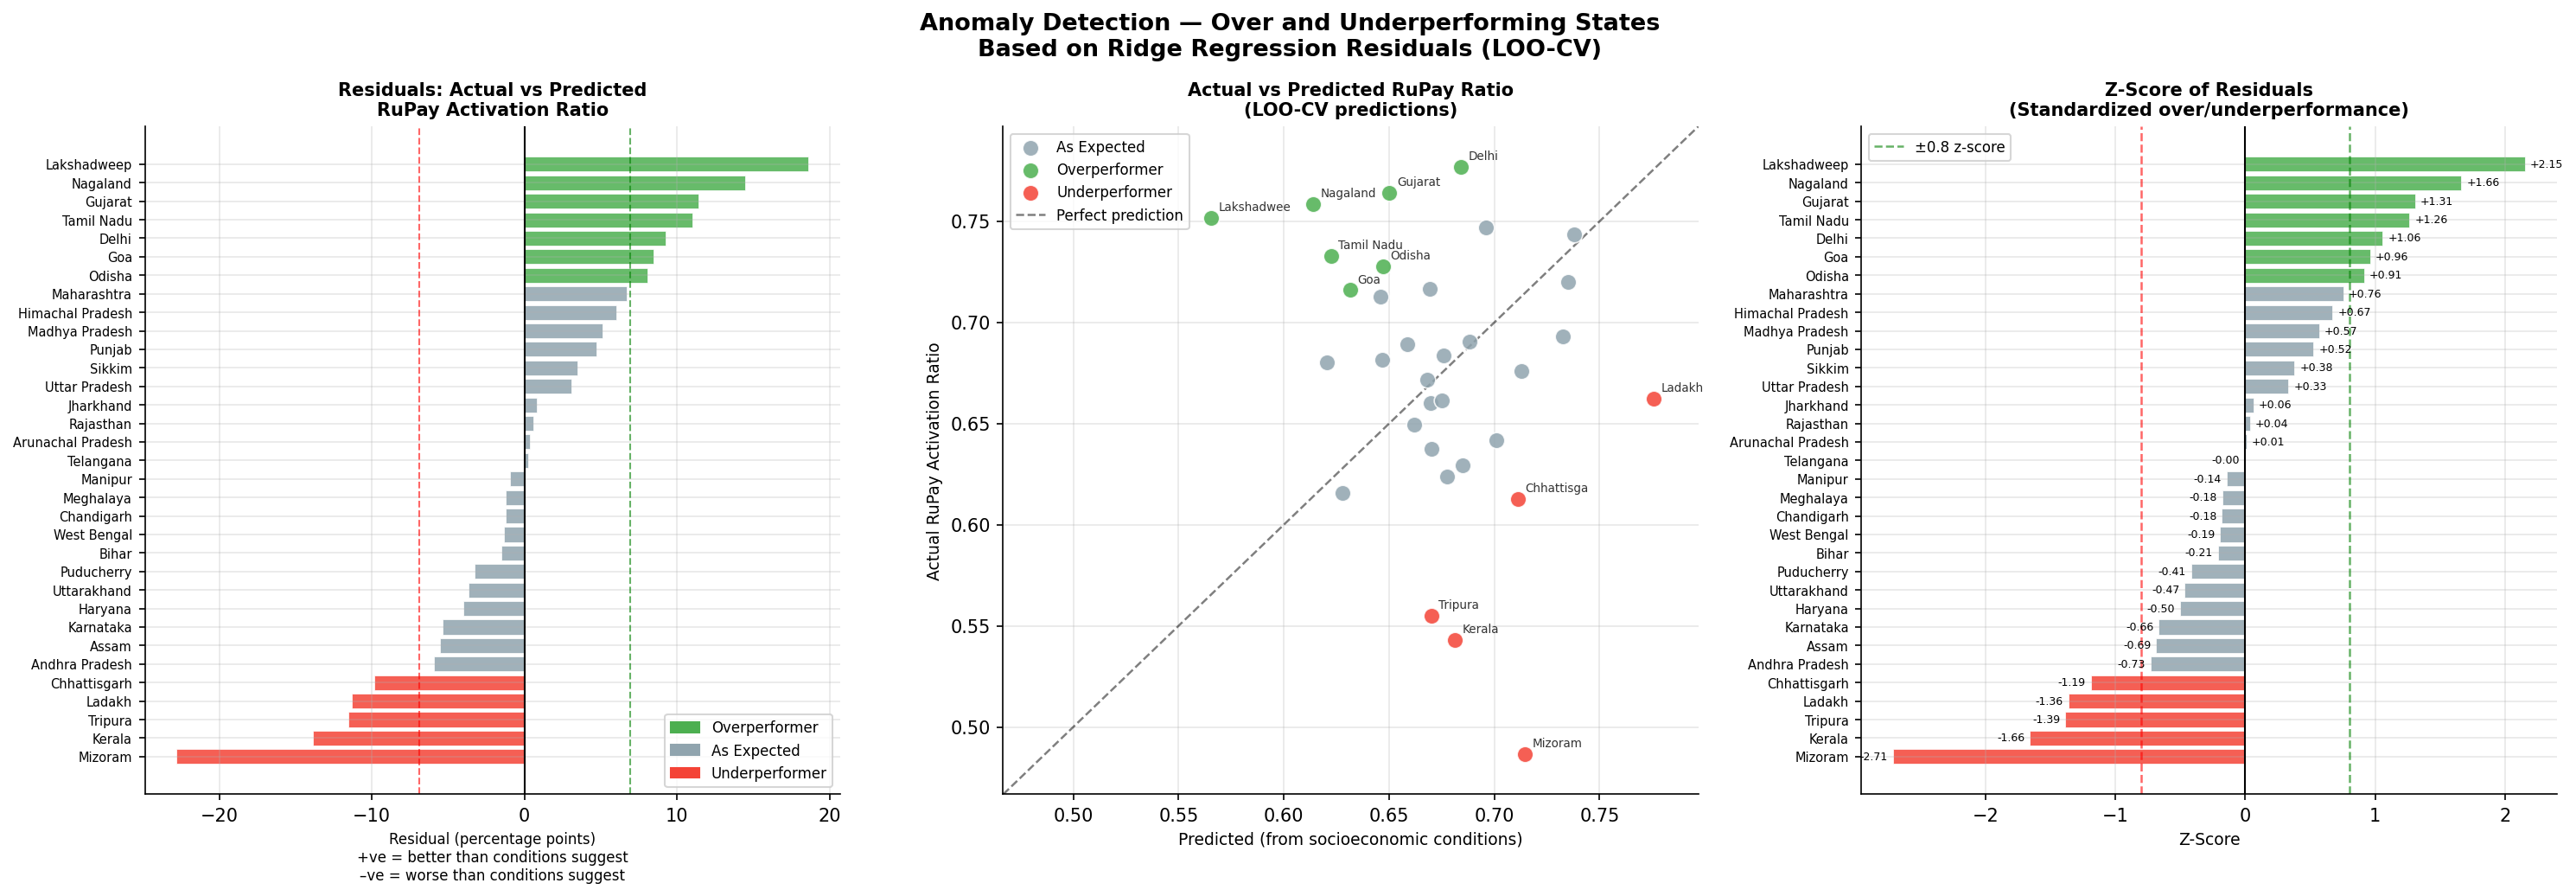


OVERPERFORMERS — Doing better than conditions suggest

  Lakshadweep
    Actual RuPay ratio   : 0.752
    Predicted ratio      : 0.565
    Outperformance       : +18.61 pp
    Z-score              : +2.15
    literacy_rate            : 81.5 (national mean 67.3 — ↑ above avg)
    rural_share              : 0.8 (national mean 0.7 — ↑ above avg)
    women_mobile_pct         : 82.6 (national mean 65.4 — ↑ above avg)

  Nagaland
    Actual RuPay ratio   : 0.758
    Predicted ratio      : 0.614
    Outperformance       : +14.43 pp
    Z-score              : +1.66
    literacy_rate            : 67.9 (national mean 67.3 — ↑ above avg)
    rural_share              : 0.7 (national mean 0.7 — ↓ below avg)
    women_mobile_pct         : 84.7 (national mean 65.4 — ↑ above avg)

  Gujarat
    Actual RuPay ratio   : 0.764
    Predicted ratio      : 0.650
    Outperformance       : +11.39 pp
    Z-score              : +1.31
    literacy_rate            : 68.0 (national mean 67.3 — ↑ above avg)
    ru

In [ ]:
# ── Step 1: Build regression model ───────────────────────────
reg_features = [
    'literacy_rate',
    'rural_share',
    'women_mobile_pct',
    'electricity_access_pct',
    'female_workforce_pct',
    'clean_water_pct',
    'literacy_gender_gap',
    'sc_share',
    'st_share',
    'avg_household_size',
    'women_property_ownership_pct',
]
reg_features = [f for f in reg_features if f in df_state.columns]

reg_df = df_state[['state_name', 'rupay_activation_ratio',
                   'Name Of The Region'] + reg_features].dropna()

X_reg = reg_df[reg_features].values
y_reg = reg_df['rupay_activation_ratio'].values

scaler_reg  = StandardScaler()
X_reg_sc    = scaler_reg.fit_transform(X_reg)

# Ridge regression with LOO-CV to get unbiased residuals
ridge = Ridge(alpha=1.0)
y_pred_loo  = cross_val_predict(ridge, X_reg_sc, y_reg, cv=LeaveOneOut())
loo_r2      = cross_val_score(ridge, X_reg_sc, y_reg,
                               cv=LeaveOneOut(), scoring='r2').mean()

print(f"\nRidge model LOO R² = {loo_r2:.3f}")
print("(Variance in RuPay ratio explained by socioeconomic conditions alone)")

# ── Step 2: Compute residuals ─────────────────────────────────
reg_df = reg_df.copy()
reg_df['predicted_rupay'] = y_pred_loo
reg_df['residual']        = reg_df['rupay_activation_ratio'] - reg_df['predicted_rupay']
reg_df['residual_pp']     = reg_df['residual'] * 100  # convert to pp
reg_df['z_residual']      = stats.zscore(reg_df['residual'])

# Classify anomaly type
threshold = 0.8   # z-score threshold
def classify(z):
    if z >  threshold: return 'Overperformer'
    if z < -threshold: return 'Underperformer'
    return 'As Expected'

reg_df['anomaly_type'] = reg_df['z_residual'].apply(classify)

print(f"\nAnomaly threshold: |z| > {threshold}")
print(reg_df['anomaly_type'].value_counts().to_string())
print()
print("Full residuals table (sorted):")
display_cols = ['state_name', 'rupay_activation_ratio',
                'predicted_rupay', 'residual_pp', 'z_residual', 'anomaly_type']
print(reg_df[display_cols].sort_values('residual_pp', ascending=False)
      .round(3).to_string(index=False))

# ── Step 3: Plots ─────────────────────────────────────────────
ANOM_COLORS = {
    'Overperformer' : '#4CAF50',
    'As Expected'   : '#90A4AE',
    'Underperformer': '#F44336',
}

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# — Plot 1: Residual bar chart —
res_sorted = reg_df.sort_values('residual_pp')
bar_cols    = [ANOM_COLORS[t] for t in res_sorted['anomaly_type']]

axes[0].barh(res_sorted['state_name'], res_sorted['residual_pp'],
             color=bar_cols, alpha=0.85, edgecolor='white', linewidth=0.4)
axes[0].axvline(0, color='black', linewidth=1)
axes[0].axvline( threshold * reg_df['residual_pp'].std(), color='green',
                linestyle='--', linewidth=1, alpha=0.6)
axes[0].axvline(-threshold * reg_df['residual_pp'].std(), color='red',
                linestyle='--', linewidth=1, alpha=0.6)
axes[0].set_title('Residuals: Actual vs Predicted\nRuPay Activation Ratio',
                  fontweight='bold', fontsize=10)
axes[0].set_xlabel('Residual (percentage points)\n'
                   '+ve = better than conditions suggest\n'
                   '–ve = worse than conditions suggest',
                   fontsize=8)
axes[0].tick_params(axis='y', labelsize=7)

over_patch  = mpatches.Patch(color='#4CAF50', label='Overperformer')
exp_patch   = mpatches.Patch(color='#90A4AE', label='As Expected')
under_patch = mpatches.Patch(color='#F44336', label='Underperformer')
axes[0].legend(handles=[over_patch, exp_patch, under_patch],
               fontsize=8, loc='lower right')

# — Plot 2: Actual vs predicted scatter —
for atype, grp in reg_df.groupby('anomaly_type'):
    axes[1].scatter(grp['predicted_rupay'], grp['rupay_activation_ratio'],
                    color=ANOM_COLORS[atype], s=80, alpha=0.85,
                    edgecolors='white', linewidth=0.8,
                    label=atype, zorder=3)

lim = [min(y_reg.min(), y_pred_loo.min()) - 0.02,
       max(y_reg.max(), y_pred_loo.max()) + 0.02]
axes[1].plot(lim, lim, 'k--', linewidth=1.2, alpha=0.5,
             label='Perfect prediction')
axes[1].set_xlim(lim); axes[1].set_ylim(lim)
axes[1].set_title('Actual vs Predicted RuPay Ratio\n(LOO-CV predictions)',
                  fontweight='bold', fontsize=10)
axes[1].set_xlabel('Predicted (from socioeconomic conditions)', fontsize=9)
axes[1].set_ylabel('Actual RuPay Activation Ratio', fontsize=9)
axes[1].legend(fontsize=8)

for _, row in reg_df[reg_df['anomaly_type'] != 'As Expected'].iterrows():
    axes[1].annotate(row['state_name'][:10],
                     (row['predicted_rupay'], row['rupay_activation_ratio']),
                     fontsize=6.5, alpha=0.8,
                     xytext=(4, 4), textcoords='offset points')

# — Plot 3: Z-score ranked —
z_sorted = reg_df.sort_values('z_residual')
z_colors = [ANOM_COLORS[t] for t in z_sorted['anomaly_type']]

axes[2].barh(z_sorted['state_name'], z_sorted['z_residual'],
             color=z_colors, alpha=0.85, edgecolor='white', linewidth=0.4)
axes[2].axvline(0,           color='black', linewidth=1)
axes[2].axvline( threshold,  color='green', linewidth=1.2,
                linestyle='--', alpha=0.6, label=f'±{threshold} z-score')
axes[2].axvline(-threshold,  color='red',   linewidth=1.2,
                linestyle='--', alpha=0.6)
axes[2].set_title('Z-Score of Residuals\n'
                  '(Standardized over/underperformance)',
                  fontweight='bold', fontsize=10)
axes[2].set_xlabel('Z-Score', fontsize=9)
axes[2].tick_params(axis='y', labelsize=7)
axes[2].legend(fontsize=8)

for i, (_, row) in enumerate(z_sorted.iterrows()):
    axes[2].text(row['z_residual'] + (0.04 if row['z_residual'] >= 0 else -0.04),
                 i, f'{row["z_residual"]:+.2f}',
                 va='center', ha='left' if row['z_residual'] >= 0 else 'right',
                 fontsize=6, color='black')

plt.suptitle('Anomaly Detection — Over and Underperforming States\n'
             'Based on Ridge Regression Residuals (LOO-CV)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results/visualisations/anomaly_detection.png', bbox_inches='tight')
plt.show()

# ── Step 4: Detailed findings for report ─────────────────────
overperformers  = reg_df[reg_df['anomaly_type'] == 'Overperformer'].sort_values(
    'residual_pp', ascending=False)
underperformers = reg_df[reg_df['anomaly_type'] == 'Underperformer'].sort_values(
    'residual_pp')

print(f"\n{'='*55}")
print("OVERPERFORMERS — Doing better than conditions suggest")
print(f"{'='*55}")
if len(overperformers) > 0:
    for _, row in overperformers.iterrows():
        print(f"\n  {row['state_name']}")
        print(f"    Actual RuPay ratio   : {row['rupay_activation_ratio']:.3f}")
        print(f"    Predicted ratio      : {row['predicted_rupay']:.3f}")
        print(f"    Outperformance       : +{row['residual_pp']:.2f} pp")
        print(f"    Z-score              : +{row['z_residual']:.2f}")
        # Show what's low about this state (so overperformance is notable)
        state_row = df_state[df_state['state_name'] == row['state_name']]
        if not state_row.empty:
            for feat in ['literacy_rate', 'rural_share', 'women_mobile_pct']:
                if feat in state_row.columns:
                    val = state_row[feat].values[0]
                    nat_mean = df_state[feat].mean()
                    direction = "↓ below" if val < nat_mean else "↑ above"
                    print(f"    {feat:<25}: {val:.1f} "
                          f"(national mean {nat_mean:.1f} — {direction} avg)")
else:
    print("  No significant overperformers at this threshold.")

print(f"\n{'='*55}")
print("UNDERPERFORMERS — Doing worse than conditions suggest")
print(f"{'='*55}")
if len(underperformers) > 0:
    for _, row in underperformers.iterrows():
        print(f"\n  {row['state_name']}")
        print(f"    Actual RuPay ratio   : {row['rupay_activation_ratio']:.3f}")
        print(f"    Predicted ratio      : {row['predicted_rupay']:.3f}")
        print(f"    Underperformance     : {row['residual_pp']:.2f} pp")
        print(f"    Z-score              : {row['z_residual']:.2f}")
        state_row = df_state[df_state['state_name'] == row['state_name']]
        if not state_row.empty:
            for feat in ['literacy_rate', 'rural_share', 'women_mobile_pct']:
                if feat in state_row.columns:
                    val = state_row[feat].values[0]
                    nat_mean = df_state[feat].mean()
                    direction = "↓ below" if val < nat_mean else "↑ above"
                    print(f"    {feat:<25}: {val:.1f} "
                          f"(national mean {nat_mean:.1f} — {direction} avg)")
else:
    print("  No significant underperformers at this threshold.")

# ── Step 5: Feature contribution to residuals ─────────────────
print(f"\n--- Which features are most correlated with residuals? ---")
print("(Positive = feature helps explain overperformance)")
for feat in reg_features:
    sub = reg_df[['residual_pp']].copy()
    sub[feat] = df_state.set_index('state_name').loc[
        reg_df['state_name'].values, feat].values
    sub = sub.dropna()
    if len(sub) > 5:
        r, p = stats.pearsonr(sub[feat], sub['residual_pp'])
        sig  = "***" if p < 0.01 else ("**" if p < 0.05 else
               ("*" if p < 0.1 else ""))
        if abs(r) > 0.2:
            print(f"  {feat:<35} r={r:+.3f}  p={p:.3f} {sig}")



In [34]:
print(df_state[['literacy_rate','electricity_access_pct','women_bank_account_pct',
                 'female_workforce_pct','rural_share','sc_share',
                 'women_property_ownership_pct','clean_water_pct']].describe().round(2))

       literacy_rate  electricity_access_pct  women_bank_account_pct  \
count          36.00                   36.00                   35.00   
mean           67.29                   98.44                   80.49   
std             8.54                    1.68                    6.61   
min            50.44                   93.25                   66.65   
25%            60.20                   97.94                   76.32   
50%            67.43                   99.10                   80.20   
75%            73.82                   99.61                   85.30   
max            84.22                  100.00                   93.80   

       female_workforce_pct  rural_share  sc_share  \
count                 36.00        36.00     36.00   
mean                  26.90         0.74     11.85   
std                    9.67         0.19      8.67   
min                    9.73         0.09      0.00   
25%                   18.19         0.69      3.08   
50%                   26.93